**OpenMM**

In [ ]:
import openmm
print(openmm.__file__)

In [ ]:
from openmm.app import *
from openmm import *
from openmm.unit import kelvin, picosecond, nanometer
from openmm import Platform


pdb = PDBFile('/home/feynman/Downloads/input_pdb/1UBQ.pdb')

forcefield = ForceField('amber19-all.xml', 'amber19/tip3pfb.xml')

modeller = Modeller(pdb.topology, pdb.positions)
modeller.addHydrogens(forcefield)

PDBFile.writeFile(modeller.topology, modeller.positions, open('/home/feynman/Downloads/input_pdb/processed.pdb', 'w'))

system = forcefield.createSystem(modeller.topology, nonbondedMethod=PME,
        nonbondedCutoff=1*nanometer, constraints=HBonds)

integrator = LangevinMiddleIntegrator(300*kelvin, 1/picosecond, 0.004*picosecond)

platform = Platform.getPlatformByName('CUDA')

simulation = Simulation(modeller.topology, system, integrator, platform)

simulation.context.setPositions(modeller.positions)

print("Minimizing...")
simulation.minimizeEnergy()

simulation.reporters.append(DCDReporter('/data/openmm_out/sample/run1/traj.dcd', 1000))

simulation.reporters.append(StateDataReporter('/data/openmm_out/sample/run1/log.txt', 1000, step=True,
        potentialEnergy=True, temperature=True))

simulation.step(100000)
print("Done")

In [ ]:
from openmm.app import *
from openmm import *
from openmm.unit import *

# -----------------------------
# Load minimized structure
# -----------------------------
pdb = PDBFile('minimized.pdb')

# -----------------------------
# Force field
# -----------------------------
forcefield = ForceField(
    'charmm36.xml',
    'implicit/obc2.xml'
)

# -----------------------------
# Build system
# -----------------------------
system = forcefield.createSystem(
    pdb.topology,
    nonbondedMethod=NoCutoff,
    constraints=HBonds
)

# -----------------------------
# Integrator
# -----------------------------
integrator = LangevinIntegrator(
    400*kelvin,
    1/picosecond,
    0.002*picosecond
)

# -----------------------------
# CUDA platform
# -----------------------------
platform = Platform.getPlatformByName('CUDA')

# -----------------------------
# Simulation object
# -----------------------------
simulation = Simulation(
    pdb.topology,
    system,
    integrator,
    platform
)

# -----------------------------
# Set positions
# -----------------------------
simulation.context.setPositions(pdb.positions)

# -----------------------------
# Initialize velocities
# -----------------------------
simulation.context.setVelocitiesToTemperature(
    400*kelvin
)

# -----------------------------
# Reporters
# -----------------------------
simulation.reporters.append(DCDReporter('/data/openmm_out/sample/run1/traj.dcd', 1000))

simulation.reporters.append(StateDataReporter('/data/openmm_out/sample/run1/log.txt', 1000, step=True,
        potentialEnergy=True, kineticEnergy=True, temperature=True, speed=True))

simulation.reporters.append(
    PDBReporter(
        'trajectory.pdb',
        1000
    )
)

# -----------------------------
# Run simulation
# -----------------------------
print("Running equilibration...")

simulation.step(1000000)

print("Done.")

In [ ]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# Load trajectory
# -----------------------------------

traj = md.load(
    '/data/openmm_out/sample/run1/traj.dcd',
    top='minimized.pdb'
)

print("Trajectory loaded")
print(traj)

# -----------------------------------
# RMSD
# -----------------------------------

rmsd = md.rmsd(
    traj,
    traj,
    0
)

# -----------------------------------
# RMSF
# -----------------------------------

protein_atoms = traj.topology.select("protein and backbone")

traj_superposed = traj.superpose(traj, 0)

rmsf = md.rmsf(
    traj_superposed,
    traj_superposed,
    0,
    atom_indices=protein_atoms
)

# -----------------------------------
# Radius of gyration
# -----------------------------------

rg = md.compute_rg(traj)

# -----------------------------------
# Native contacts Q(t)
# -----------------------------------

native_pairs = traj.topology.select_pairs(
    'protein and name CA',
    'protein and name CA'
)

# Remove nearby sequence neighbors
native_pairs = np.array([
    pair for pair in native_pairs
    if abs(pair[0] - pair[1]) > 3
])

distances = md.compute_distances(
    traj,
    native_pairs
)

native_distances = distances[0]

contact_cutoff = 0.8  # nm

native_contacts = native_distances < contact_cutoff

Q = []

for frame in distances:
    contacts_now = frame < contact_cutoff

    q = np.sum(
        contacts_now & native_contacts
    ) / np.sum(native_contacts)

    Q.append(q)

Q = np.array(Q)

# -----------------------------------
# Plots
# -----------------------------------

fig, axs = plt.subplots(2, 2, figsize=(12,10))

# RMSD
axs[0,0].plot(rmsd)
axs[0,0].set_title("RMSD")
axs[0,0].set_ylabel("nm")

# RMSF
axs[0,1].plot(rmsf)
axs[0,1].set_title("RMSF")
axs[0,1].set_ylabel("nm")

# Radius of gyration
axs[1,0].plot(rg)
axs[1,0].set_title("Radius of Gyration")
axs[1,0].set_ylabel("nm")

# Q(t)
axs[1,1].plot(Q)
axs[1,1].set_title("Native Contacts Q(t)")
axs[1,1].set_ylabel("Q")

plt.tight_layout()
plt.show()

# WT 1PGA 50 ns simulation using CHARMM36m

In [3]:
%autosave 60

from openmm.app import *
from openmm import *
from openmm.unit import picosecond, kelvin, picoseconds
from sys import stdout

# =========================================================
# LOAD STRUCTURE
# =========================================================

pdb = PDBFile(
    '/home/feynman/Downloads/foldx5_Linux/1PGA_Repair.pdb'
)

# =========================================================
# FORCE FIELD
# =========================================================

forcefield = ForceField(
    'charmm36.xml',
    'implicit/obc2.xml'
)

# =========================================================
# ADD HYDROGENS
# =========================================================

modeller = Modeller(
    pdb.topology,
    pdb.positions
)

modeller.addHydrogens(forcefield)

# =========================================================
# BUILD SYSTEM
# =========================================================

system = forcefield.createSystem(
    modeller.topology,
    nonbondedMethod=NoCutoff,
    constraints=HBonds
)

# =========================================================
# INTEGRATOR
# =========================================================

temperature = 400 * kelvin

integrator = LangevinIntegrator(
    temperature,
    1/picosecond,
    0.002*picoseconds
)

# =========================================================
# CUDA PLATFORM
# =========================================================

platform = Platform.getPlatformByName('CUDA')

properties = {
    'CudaPrecision': 'mixed'
}

# =========================================================
# SIMULATION OBJECT
# =========================================================

simulation = Simulation(
    modeller.topology,
    system,
    integrator,
    platform,
    properties
)

# =========================================================
# INITIALIZE POSITIONS + VELOCITIES
# =========================================================

simulation.context.setPositions(modeller.positions)

simulation.context.setVelocitiesToTemperature(
    temperature
)

# =========================================================
# ENERGY MINIMIZATION
# =========================================================

print("Minimizing energy...")

simulation.minimizeEnergy()

print("Minimization complete.")

# =========================================================
# SAVE MINIMIZED STRUCTURE
# =========================================================

positions = simulation.context.getState(
    getPositions=True
).getPositions()

with open('/data/openmm_out/1PGA_mutations/wt_1pga/wt_minimized.pdb', 'w') as f:

    PDBFile.writeFile(
        simulation.topology,
        positions,
        f
    )

print("Saved minimized structure.")

# =========================================================
# EQUILIBRATION
# =========================================================

print("Starting equilibration...")

simulation.step(6250000)

print("Equilibration complete.")

# =========================================================
# REPORTERS
# =========================================================

simulation.reporters.append(
    DCDReporter(
        '/data/openmm_out/1PGA_mutations/wt_1pga/wt_trajectory.dcd',
        5000
    )
)

simulation.reporters.append(
    StateDataReporter(
        '/data/openmm_out/1PGA_mutations/wt_1pga/wt_log.csv',
        5000,
        step=True,
        potentialEnergy=True,
        kineticEnergy=True,
        totalEnergy=True,
        temperature=True,
        speed=True,
        progress=True,
        remainingTime=True,
        totalSteps=62500000,
        separator=','
    )
)

# LIVE OUTPUT INSIDE NOTEBOOK
simulation.reporters.append(
    StateDataReporter(
        stdout,
        5000,
        step=True,
        temperature=True,
        potentialEnergy=True,
        speed=True,
        progress=True,
        remainingTime=True,
        totalSteps=62500000,
        separator=' | '
    )
)

# =========================================================
# PRODUCTION RUN
# =========================================================

print("Starting production run...")

# 125 ns
# timestep = 2 fs
# total steps = 62,500,000

simulation.step(62500000)

print("Production run complete.")

# =========================================================
# SAVE FINAL STRUCTURE
# =========================================================

final_positions = simulation.context.getState(
    getPositions=True
).getPositions()

with open('/data/openmm_out/1PGA_mutations/wt_1pga/wt_final.pdb', 'w') as f:

    PDBFile.writeFile(
        simulation.topology,
        final_positions,
        f
    )

print("Saved final structure.")

Autosaving every 60 seconds
Minimizing energy...
Minimization complete.
Saved minimized structure.
Starting equilibration...
Equilibration complete.
Starting production run...
#"Progress (%)" | "Step" | "Potential Energy (kJ/mole)" | "Temperature (K)" | "Speed (ns/day)" | "Time Remaining"
10.0% | 6255000 | -2266.3580627691967 | 417.83766078899 | 0 | --
10.0% | 6260000 | -2112.803193418801 | 406.69923068496297 | 723 | 3:43:52
10.0% | 6265000 | -2512.9274838003216 | 424.1335081603921 | 725 | 3:43:28
10.0% | 6270000 | -2316.532529634284 | 404.877171034823 | 724 | 3:43:41
10.0% | 6275000 | -2033.8106169252092 | 397.31492362191983 | 723 | 3:43:49
10.0% | 6280000 | -2360.5220891357294 | 397.70221104557277 | 723 | 3:43:57
10.1% | 6285000 | -1977.0738833725218 | 392.83754925139056 | 723 | 3:43:47
10.1% | 6290000 | -2216.462990204521 | 414.545740401003 | 724 | 3:43:39
10.1% | 6295000 | -1929.1898469569405 | 403.0732472301942 | 724 | 3:43:32
10.1% | 6300000 | -2110.5071810303016 | 402.0704140001

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
<mdtraj.Trajectory with 12500 frames, 855 atoms, 56 residues, without unitcells>


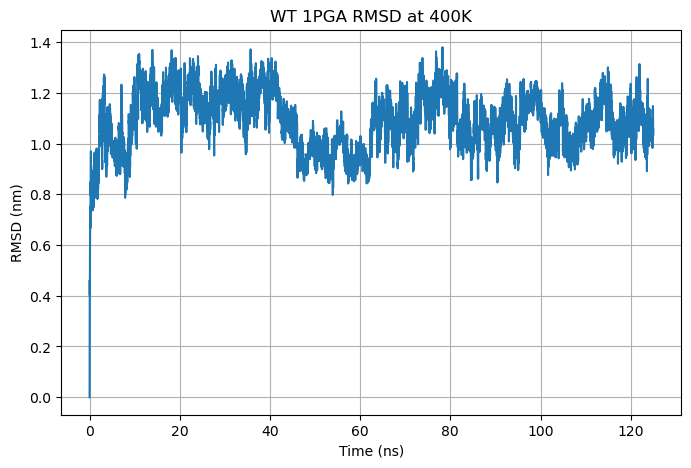

In [4]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# LOAD TRAJECTORY
# ============================================

traj = md.load(
    '/data/openmm_out/1PGA_mutations/wt_1pga/wt_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/wt_1pga/wt_minimized.pdb'
)

print(traj)

# ============================================
# RMSD CALCULATION
# ============================================

rmsd_wt = md.rmsd(
    traj,
    traj,
    0
)

# ============================================
# TIME AXIS (ns)
# ============================================

time_ns = np.arange(len(traj)) * 0.01

# ============================================
# PLOT
# ============================================

plt.figure(figsize=(8,5))

plt.plot(time_ns, rmsd_wt)

plt.xlabel('Time (ns)')
plt.ylabel('RMSD (nm)')
plt.title('WT 1PGA RMSD at 400K')

plt.grid(True)

plt.show()

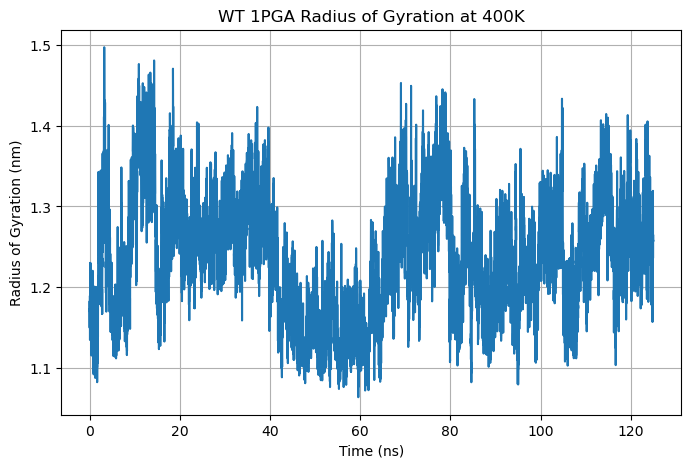

In [5]:
# ============================================
# RADIUS OF GYRATION
# ============================================

rg_wt = md.compute_rg(traj)

plt.figure(figsize=(8,5))

plt.plot(time_ns, rg_wt)

plt.xlabel('Time (ns)')
plt.ylabel('Radius of Gyration (nm)')
plt.title('WT 1PGA Radius of Gyration at 400K')

plt.grid(True)

plt.show()

## Simulate for one mutant (V21P)

In [16]:
%autosave 60

from openmm.app import *
from openmm import *
from openmm.unit import *
from sys import stdout

# =========================================================
# LOAD STRUCTURE
# =========================================================

pdb = PDBFile(
    '/home/feynman/projects/codes/notebooks/mutant_pdbs/V21P.pdb'
)

# =========================================================
# FORCE FIELD
# =========================================================

forcefield = ForceField(
    'charmm36.xml',
    'implicit/obc2.xml'
)

# =========================================================
# ADD HYDROGENS
# =========================================================

modeller = Modeller(
    pdb.topology,
    pdb.positions
)

modeller.addHydrogens(forcefield)

# =========================================================
# BUILD SYSTEM
# =========================================================

system = forcefield.createSystem(
    modeller.topology,
    nonbondedMethod=NoCutoff,
    constraints=HBonds
)

# =========================================================
# INTEGRATOR
# =========================================================

temperature = 400 * kelvin

integrator = LangevinIntegrator(
    temperature,
    1/picosecond,
    0.002*picosecond
)

# =========================================================
# CUDA PLATFORM
# =========================================================

platform = Platform.getPlatformByName('CUDA')

properties = {
    'CudaPrecision': 'mixed'
}

# =========================================================
# SIMULATION OBJECT
# =========================================================

simulation = Simulation(
    modeller.topology,
    system,
    integrator,
    platform,
    properties
)

# =========================================================
# INITIALIZE POSITIONS + VELOCITIES
# =========================================================

simulation.context.setPositions(modeller.positions)

simulation.context.setVelocitiesToTemperature(
    temperature
)

# =========================================================
# ENERGY MINIMIZATION
# =========================================================

print("Minimizing energy...")

simulation.minimizeEnergy()

print("Minimization complete.")

# =========================================================
# SAVE MINIMIZED STRUCTURE
# =========================================================

positions = simulation.context.getState(
    getPositions=True
).getPositions()

with open('/data/openmm_out/1PGA_mutations/V21P/V21P_minimized.pdb', 'w') as f:

    PDBFile.writeFile(
        simulation.topology,
        positions,
        f
    )

print("Saved minimized structure.")

# =========================================================
# EQUILIBRATION
# =========================================================

print("Starting equilibration...")

simulation.step(2500000)

print("Equilibration complete.")

# =========================================================
# REPORTERS
# =========================================================

simulation.reporters.append(
    DCDReporter(
        '/data/openmm_out/1PGA_mutations/V21P/V21P_trajectory.dcd',
        5000
    )
)

simulation.reporters.append(
    StateDataReporter(
        '/data/openmm_out/1PGA_mutations/V21P/V21P_log.csv',
        5000,
        step=True,
        potentialEnergy=True,
        kineticEnergy=True,
        totalEnergy=True,
        temperature=True,
        speed=True,
        progress=True,
        remainingTime=True,
        totalSteps=25000000,
        separator=','
    )
)

# LIVE OUTPUT INSIDE NOTEBOOK
simulation.reporters.append(
    StateDataReporter(
        stdout,
        5000,
        step=True,
        temperature=True,
        potentialEnergy=True,
        speed=True,
        progress=True,
        remainingTime=True,
        totalSteps=25000000,
        separator=' | '
    )
)

# =========================================================
# PRODUCTION RUN
# =========================================================

print("Starting production run...")

# 50 ns
# timestep = 2 fs
# total steps = 25,000,000

simulation.step(25000000)

print("Production run complete.")

# =========================================================
# SAVE FINAL STRUCTURE
# =========================================================

final_positions = simulation.context.getState(
    getPositions=True
).getPositions()

with open('/data/openmm_out/1PGA_mutations/V21P/V21P_final.pdb', 'w') as f:

    PDBFile.writeFile(
        simulation.topology,
        final_positions,
        f
    )

print("Saved final structure.")

Autosaving every 60 seconds
Minimizing energy...
Minimization complete.
Saved minimized structure.
Starting equilibration...
Equilibration complete.
Starting production run...
#"Progress (%)" | "Step" | "Potential Energy (kJ/mole)" | "Temperature (K)" | "Speed (ns/day)" | "Time Remaining"
10.0% | 2505000 | -2208.754231863535 | 412.84382057066506 | 0 | --
10.0% | 2510000 | -2124.636530410684 | 412.56722123671915 | 2.22e+03 | 29:14
10.1% | 2515000 | -2141.6598273393256 | 423.7672926370579 | 2.21e+03 | 29:15
10.1% | 2520000 | -2233.039880983321 | 404.9369869101526 | 2.21e+03 | 29:15
10.1% | 2525000 | -2208.473515618311 | 407.34892581758913 | 2.21e+03 | 29:14
10.1% | 2530000 | -2177.712481144149 | 390.79882860381525 | 2.21e+03 | 29:13
10.1% | 2535000 | -2213.3153974102156 | 386.2847068646233 | 2.22e+03 | 29:11
10.2% | 2540000 | -2143.0126497760575 | 408.0791177762918 | 2.22e+03 | 29:11
10.2% | 2545000 | -2318.025999190512 | 404.15332866355794 | 2.22e+03 | 29:10
10.2% | 2550000 | -2346.5472

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
<mdtraj.Trajectory with 12500 frames, 853 atoms, 56 residues, without unitcells>


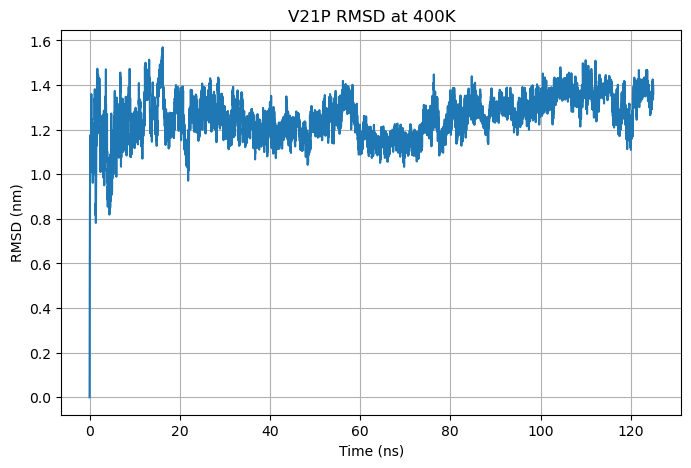

In [6]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# LOAD TRAJECTORY
# ============================================

traj = md.load(
    '/data/openmm_out/1PGA_mutations/V21P/V21P_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/V21P/V21P_minimized.pdb'
)

print(traj)

# ============================================
# RMSD CALCULATION
# ============================================

rmsd_v21p = md.rmsd(
    traj,
    traj,
    0
)

# ============================================
# TIME AXIS (ns)
# ============================================

time_ns = np.arange(len(traj)) * 0.01

# ============================================
# PLOT
# ============================================

plt.figure(figsize=(8,5))

plt.plot(time_ns, rmsd_v21p)

plt.xlabel('Time (ns)')
plt.ylabel('RMSD (nm)')
plt.title('V21P RMSD at 400K')

plt.grid(True)

plt.show()

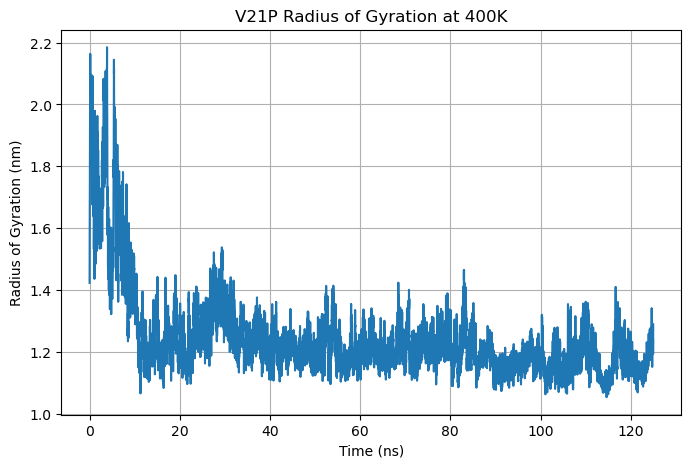

In [7]:
# ============================================
# RADIUS OF GYRATION
# ============================================

rg_v21p = md.compute_rg(traj)

plt.figure(figsize=(8,5))

plt.plot(time_ns, rg_v21p)

plt.xlabel('Time (ns)')
plt.ylabel('Radius of Gyration (nm)')
plt.title('V21P Radius of Gyration at 400K')

plt.grid(True)

plt.show()

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
<mdtraj.Trajectory with 12500 frames, 852 atoms, 56 residues, without unitcells>


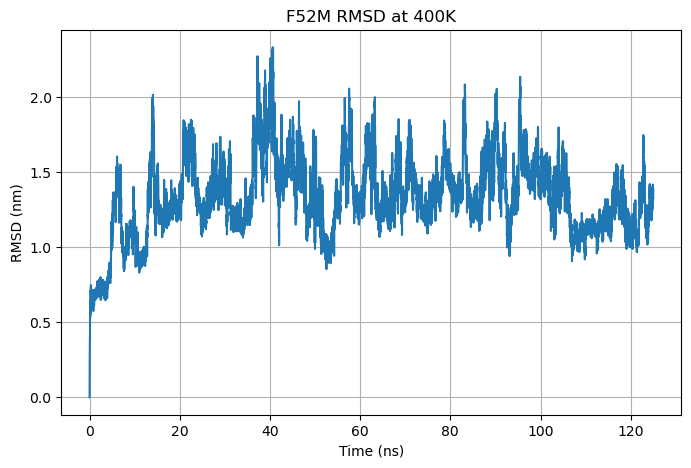

In [19]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# LOAD TRAJECTORY
# ============================================

traj = md.load(
    '/data/openmm_out/1PGA_mutations/F52M/F52M_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/F52M/F52M_minimized.pdb'
)

print(traj)

# ============================================
# RMSD CALCULATION
# ============================================

rmsd_f52m = md.rmsd(
    traj,
    traj,
    0
)

# ============================================
# TIME AXIS (ns)
# ============================================

time_ns = np.arange(len(traj)) * 0.01

# ============================================
# PLOT
# ============================================

plt.figure(figsize=(8,5))

plt.plot(time_ns, rmsd_f52m)

plt.xlabel('Time (ns)')
plt.ylabel('RMSD (nm)')
plt.title('F52M RMSD at 400K')

plt.grid(True)

plt.show()

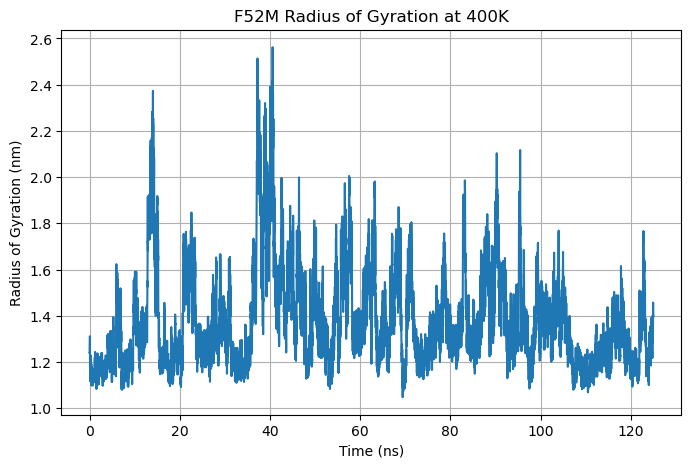

In [20]:
# ============================================
# RADIUS OF GYRATION
# ============================================

rg_f52m = md.compute_rg(traj)

plt.figure(figsize=(8,5))

plt.plot(time_ns, rg_f52m)

plt.xlabel('Time (ns)')
plt.ylabel('Radius of Gyration (nm)')
plt.title('F52M Radius of Gyration at 400K')

plt.grid(True)

plt.show()

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


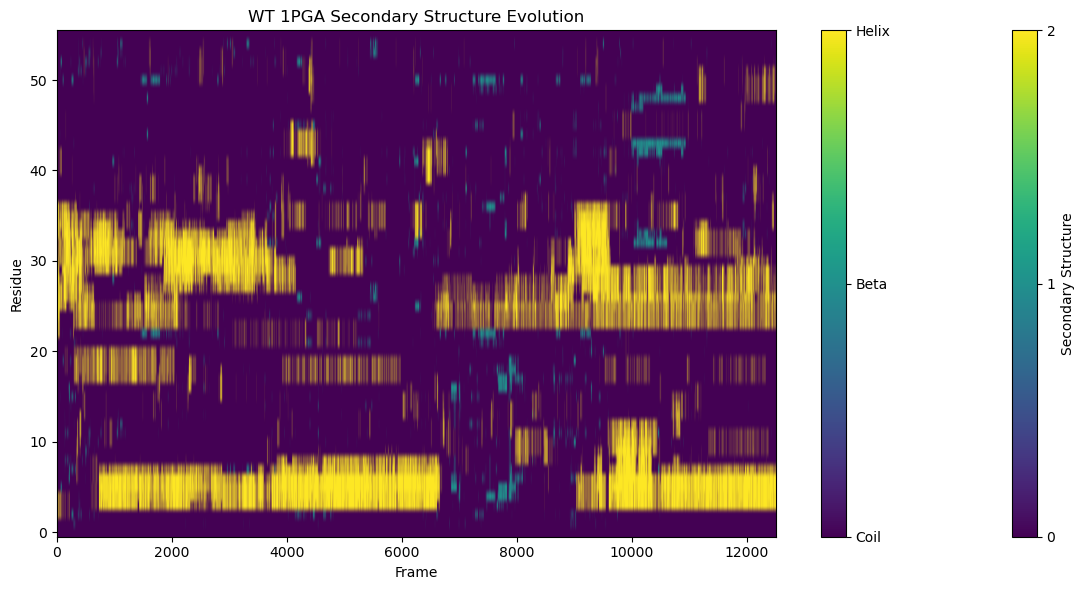

In [8]:
# WT secondary structure plot

import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# LOAD TRAJECTORY
# =====================================================

traj = md.load(
    '/data/openmm_out/1PGA_mutations/wt_1pga/wt_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/wt_1pga/wt_final.pdb'
)

# =====================================================
# COMPUTE DSSP
# =====================================================

dssp = md.compute_dssp(traj)

# =====================================================
# CONVERT TO NUMERIC
# =====================================================

# H = helix
# E = beta sheet
# C = coil/other

mapping = {
    'H': 2,
    'E': 1
}

numeric_dssp = np.zeros(dssp.shape)

for i in range(dssp.shape[0]):
    for j in range(dssp.shape[1]):

        numeric_dssp[i, j] = mapping.get(
            dssp[i, j],
            0
        )

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(12,6))

plt.imshow(
    numeric_dssp.T,
    aspect='auto',
    origin='lower',
    cmap='viridis'
)

plt.colorbar(
    ticks=[0,1,2],
    label='Secondary Structure'
)

plt.clim(0,2)

cbar = plt.colorbar()
cbar.set_ticks([0,1,2])
cbar.set_ticklabels(['Coil','Beta','Helix'])

plt.xlabel('Frame')
plt.ylabel('Residue')

plt.title('WT 1PGA Secondary Structure Evolution')

plt.tight_layout()
plt.show()

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


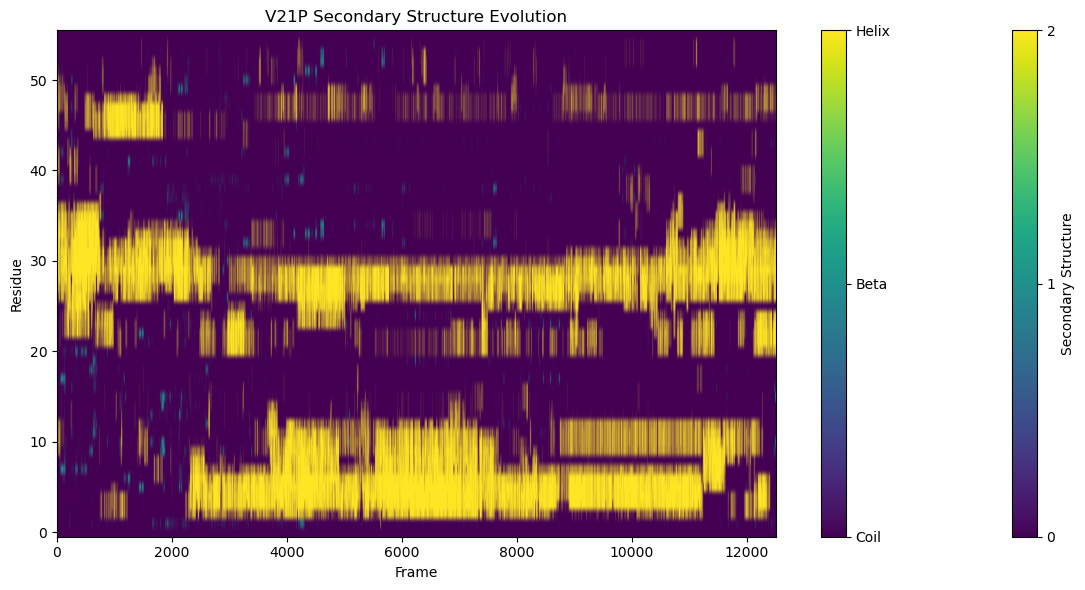

In [9]:
# WT secondary structure plot

import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# LOAD TRAJECTORY
# =====================================================

traj = md.load(
    '/data/openmm_out/1PGA_mutations/V21P/V21P_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/V21P/V21P_final.pdb'
)

# =====================================================
# COMPUTE DSSP
# =====================================================

dssp = md.compute_dssp(traj)

# =====================================================
# CONVERT TO NUMERIC
# =====================================================

# H = helix
# E = beta sheet
# C = coil/other

mapping = {
    'H': 2,
    'E': 1
}

numeric_dssp = np.zeros(dssp.shape)

for i in range(dssp.shape[0]):
    for j in range(dssp.shape[1]):

        numeric_dssp[i, j] = mapping.get(
            dssp[i, j],
            0
        )

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(12,6))

plt.imshow(
    numeric_dssp.T,
    aspect='auto',
    origin='lower',
    cmap='viridis'
)

plt.colorbar(
    ticks=[0,1,2],
    label='Secondary Structure'
)

plt.clim(0,2)

cbar = plt.colorbar()
cbar.set_ticks([0,1,2])
cbar.set_ticklabels(['Coil','Beta','Helix'])

plt.xlabel('Frame')
plt.ylabel('Residue')

plt.title('V21P Secondary Structure Evolution')

plt.tight_layout()
plt.show()

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


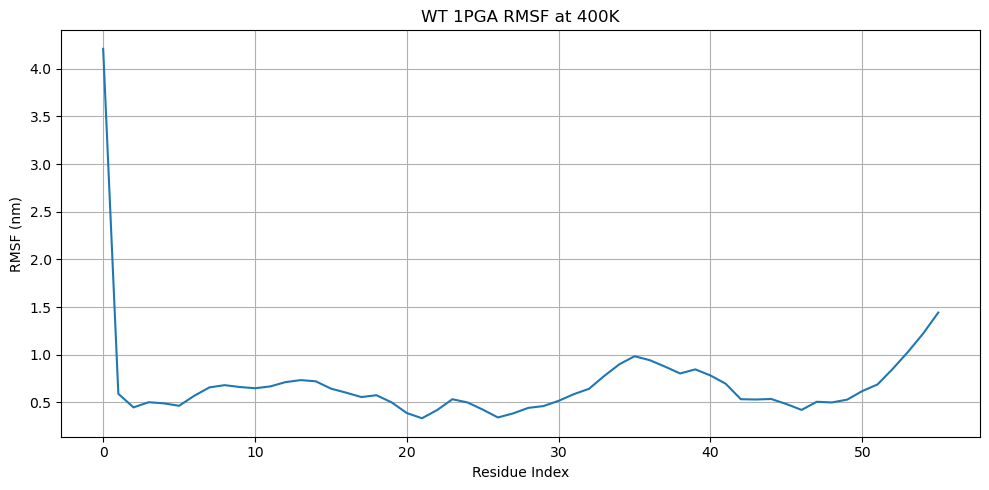

In [10]:
# RMSF plot for WT

import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# LOAD WT TRAJECTORY
# =====================================================

traj = md.load(
    '/data/openmm_out/1PGA_mutations/wt_1pga/wt_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/wt_1pga/wt_final.pdb'
)

# =====================================================
# ALIGN TRAJECTORY
# =====================================================

traj.superpose(traj[0])

# =====================================================
# SELECT CA ATOMS
# =====================================================

ca_atoms = traj.topology.select('name CA')

# =====================================================
# COMPUTE RMSF
# =====================================================

rmsf = md.rmsf(
    traj,
    traj[0],
    atom_indices=ca_atoms
)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(rmsf)

plt.xlabel('Residue Index')
plt.ylabel('RMSF (nm)')

plt.title('WT 1PGA RMSF at 400K')

plt.grid(True)

plt.tight_layout()
plt.show()

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


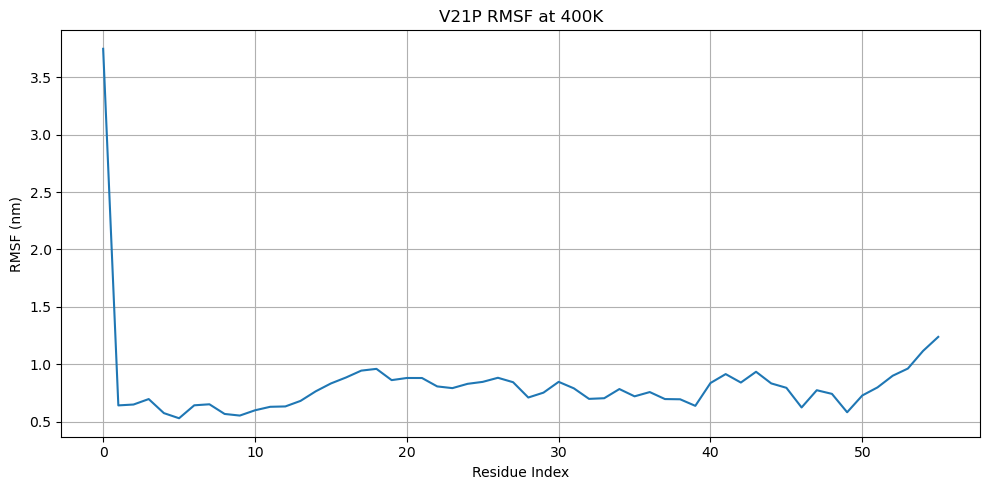

In [11]:
# RMSF plot for V21P

import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# LOAD V21P TRAJECTORY
# =====================================================

traj = md.load(
    '/data/openmm_out/1PGA_mutations/V21P/V21P_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/V21P/V21P_final.pdb'
)

# =====================================================
# ALIGN TRAJECTORY
# =====================================================

traj.superpose(traj[0])

# =====================================================
# SELECT CA ATOMS
# =====================================================

ca_atoms = traj.topology.select('name CA')

# =====================================================
# COMPUTE RMSF
# =====================================================

rmsf = md.rmsf(
    traj,
    traj[0],
    atom_indices=ca_atoms
)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(rmsf)

plt.xlabel('Residue Index')
plt.ylabel('RMSF (nm)')

plt.title('V21P RMSF at 400K')

plt.grid(True)

plt.tight_layout()
plt.show()

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


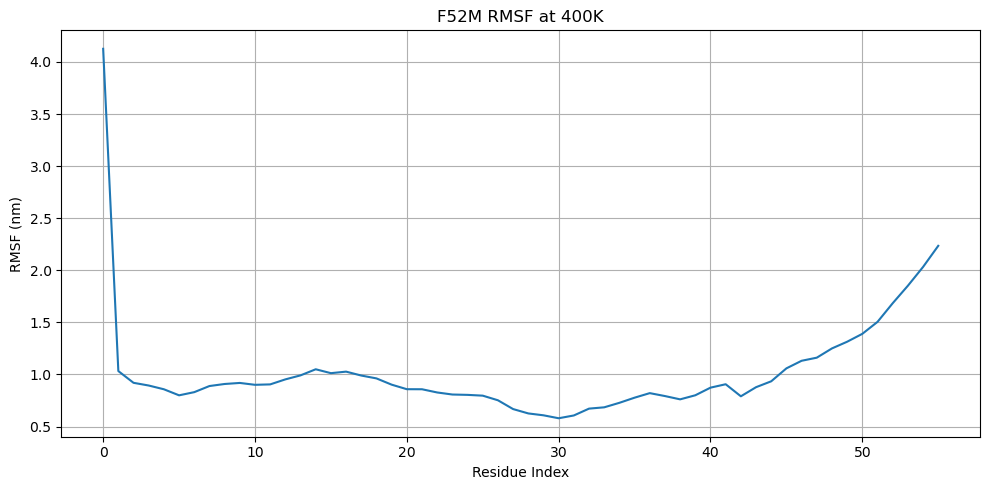

In [1]:
# RMSF plot for V21P

import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# LOAD V21P TRAJECTORY
# =====================================================

traj = md.load(
    '/data/openmm_out/1PGA_mutations/F52M/F52M_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/F52M/F52M_final.pdb'
)

# =====================================================
# ALIGN TRAJECTORY
# =====================================================

traj.superpose(traj[0])

# =====================================================
# SELECT CA ATOMS
# =====================================================

ca_atoms = traj.topology.select('name CA')

# =====================================================
# COMPUTE RMSF
# =====================================================

rmsf = md.rmsf(
    traj,
    traj[0],
    atom_indices=ca_atoms
)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(rmsf)

plt.xlabel('Residue Index')
plt.ylabel('RMSF (nm)')

plt.title('F52M RMSF at 400K')

plt.grid(True)

plt.tight_layout()
plt.show()

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


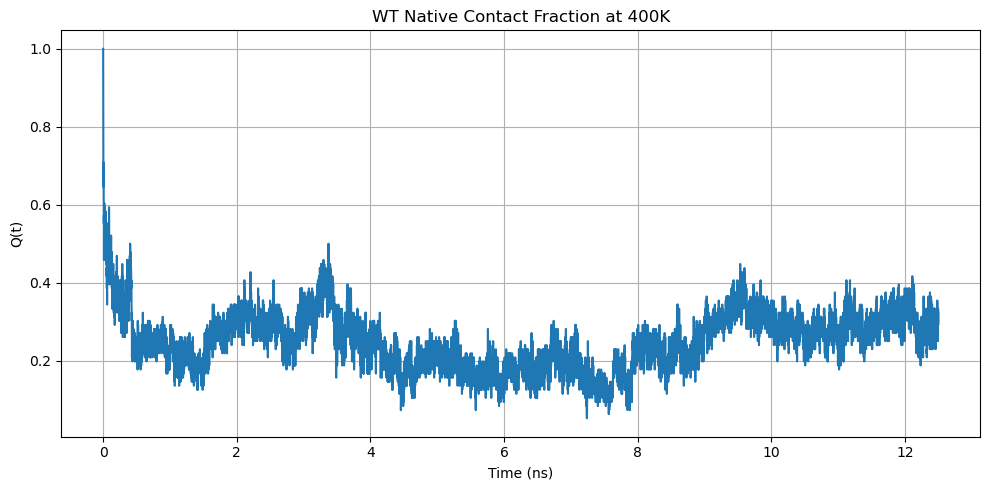

In [12]:
# WT native contact fraction Q(t)

import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# LOAD TRAJECTORY
# =====================================================

traj = md.load(
    '/data/openmm_out/1PGA_mutations/wt_1pga/wt_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/wt_1pga/wt_final.pdb'
)

# =====================================================
# DEFINE NATIVE STRUCTURE
# =====================================================

native = traj[0]

# =====================================================
# GET NATIVE CONTACTS
# =====================================================

contacts = md.compute_contacts(
    native,
    scheme='ca'
)[0]

pairs = md.compute_contacts(
    native,
    scheme='ca'
)[1]

# =====================================================
# DEFINE NATIVE CONTACTS
# cutoff = 0.8 nm
# =====================================================

native_contacts = pairs[contacts[0] < 0.8]

# =====================================================
# COMPUTE CONTACTS THROUGH TRAJECTORY
# =====================================================

distances, _ = md.compute_contacts(
    traj,
    contacts=native_contacts,
    scheme='ca'
)

# =====================================================
# COMPUTE Q(t)
# =====================================================

Q = np.mean(
    distances < 0.8,
    axis=1
)

# =====================================================
# TIME AXIS
# =====================================================

time_ns = traj.time / 1000

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(time_ns, Q)

plt.xlabel('Time (ns)')
plt.ylabel('Q(t)')

plt.title('WT Native Contact Fraction at 400K')

plt.grid(True)

plt.tight_layout()
plt.show()

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


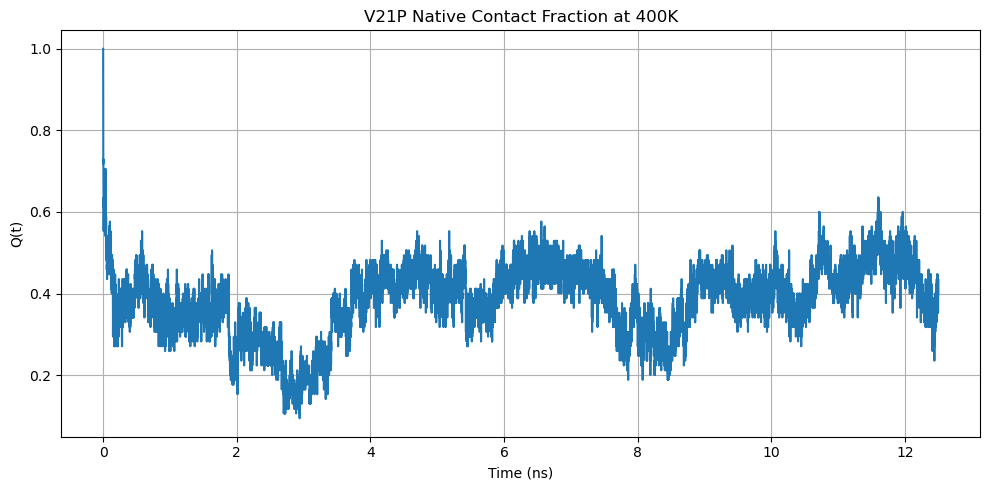

In [13]:
# V21P native contact fraction Q(t)

import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# LOAD TRAJECTORY
# =====================================================

traj = md.load(
    '/data/openmm_out/1PGA_mutations/V21P/V21P_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/V21P/V21P_final.pdb'
)

# =====================================================
# DEFINE NATIVE STRUCTURE
# =====================================================

native = traj[0]

# =====================================================
# GET NATIVE CONTACTS
# =====================================================

contacts = md.compute_contacts(
    native,
    scheme='ca'
)[0]

pairs = md.compute_contacts(
    native,
    scheme='ca'
)[1]

# =====================================================
# DEFINE NATIVE CONTACTS
# cutoff = 0.8 nm
# =====================================================

native_contacts = pairs[contacts[0] < 0.8]

# =====================================================
# COMPUTE CONTACTS THROUGH TRAJECTORY
# =====================================================

distances, _ = md.compute_contacts(
    traj,
    contacts=native_contacts,
    scheme='ca'
)

# =====================================================
# COMPUTE Q(t)
# =====================================================

Q = np.mean(
    distances < 0.8,
    axis=1
)

# =====================================================
# TIME AXIS
# =====================================================

time_ns = traj.time / 1000

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(time_ns, Q)

plt.xlabel('Time (ns)')
plt.ylabel('Q(t)')

plt.title('V21P Native Contact Fraction at 400K')

plt.grid(True)

plt.tight_layout()
plt.show()

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


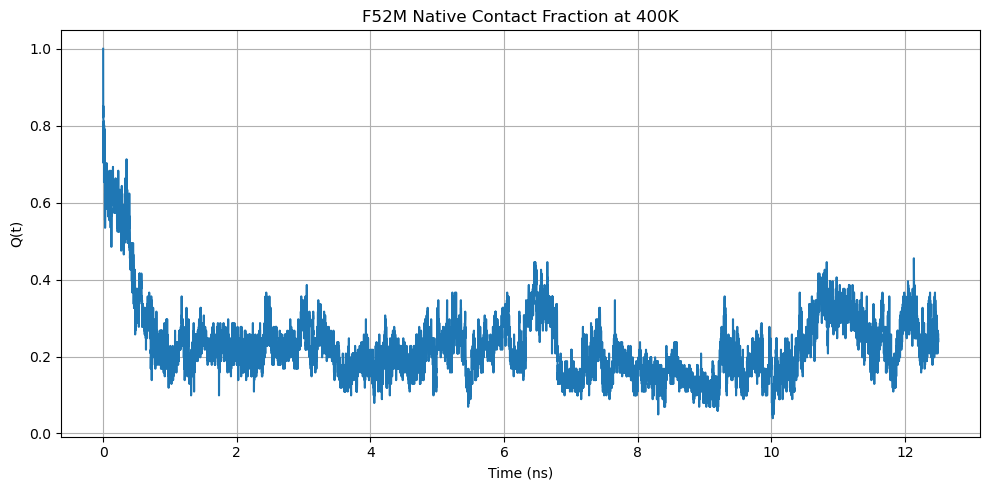

In [14]:
# V21P native contact fraction Q(t)

import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# LOAD TRAJECTORY
# =====================================================

traj = md.load(
    '/data/openmm_out/1PGA_mutations/F52M/F52M_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/F52M/F52M_final.pdb'
)

# =====================================================
# DEFINE NATIVE STRUCTURE
# =====================================================

native = traj[0]

# =====================================================
# GET NATIVE CONTACTS
# =====================================================

contacts = md.compute_contacts(
    native,
    scheme='ca'
)[0]

pairs = md.compute_contacts(
    native,
    scheme='ca'
)[1]

# =====================================================
# DEFINE NATIVE CONTACTS
# cutoff = 0.8 nm
# =====================================================

native_contacts = pairs[contacts[0] < 0.8]

# =====================================================
# COMPUTE CONTACTS THROUGH TRAJECTORY
# =====================================================

distances, _ = md.compute_contacts(
    traj,
    contacts=native_contacts,
    scheme='ca'
)

# =====================================================
# COMPUTE Q(t)
# =====================================================

Q = np.mean(
    distances < 0.8,
    axis=1
)

# =====================================================
# TIME AXIS
# =====================================================

time_ns = traj.time / 1000

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(time_ns, Q)

plt.xlabel('Time (ns)')
plt.ylabel('Q(t)')

plt.title('F52M Native Contact Fraction at 400K')

plt.grid(True)

plt.tight_layout()
plt.show()

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


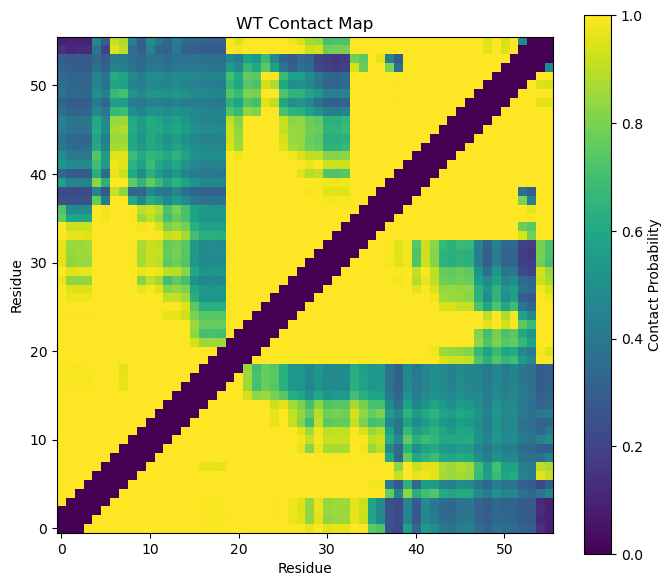

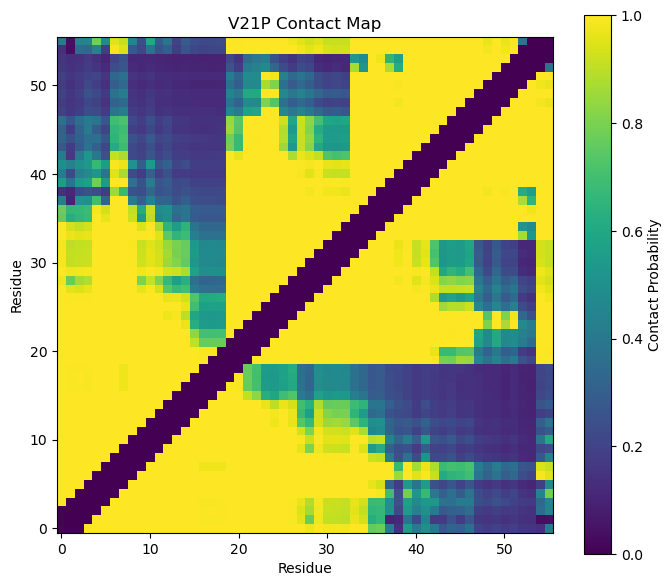

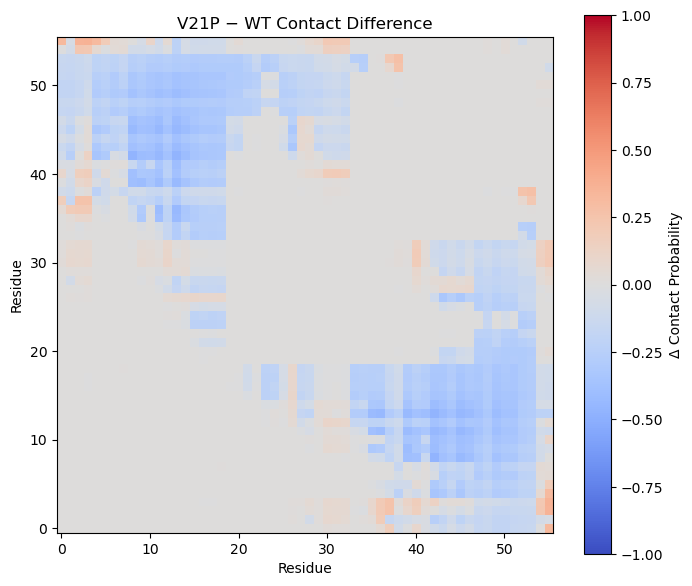

In [31]:
# WT AND V21P CONTACT MAP

import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# LOAD TRAJECTORIES
# =========================================================

wt = md.load(
    '/data/openmm_out/1PGA_mutations/wt_1pga/wt_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/wt_1pga/wt_final.pdb'
)

mut = md.load(
    '/data/openmm_out/1PGA_mutations/V21P/V21P_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/V21P/V21P_final.pdb'
)

# =========================================================
# SELECT CA ATOMS
# =========================================================

wt_ca = wt.topology.select('name CA')
mut_ca = mut.topology.select('name CA')

n_res = len(wt_ca)

# =========================================================
# CREATE RESIDUE PAIRS
# =========================================================

pairs = []

for i in range(n_res):
    for j in range(i+3, n_res):  
        pairs.append([i, j])

pairs = np.array(pairs)

# =========================================================
# COMPUTE DISTANCES
# =========================================================

wt_dist = md.compute_distances(wt, pairs)
mut_dist = md.compute_distances(mut, pairs)

# =========================================================
# DEFINE CONTACTS
# cutoff = 0.8 nm
# =========================================================

cutoff = 0.8

wt_contacts = wt_dist < cutoff
mut_contacts = mut_dist < cutoff

# =========================================================
# CONTACT PROBABILITY MATRICES
# =========================================================

wt_matrix = np.zeros((n_res, n_res))
mut_matrix = np.zeros((n_res, n_res))

for idx, (i, j) in enumerate(pairs):

    wt_prob = np.mean(wt_contacts[:, idx])
    mut_prob = np.mean(mut_contacts[:, idx])

    wt_matrix[i, j] = wt_prob
    wt_matrix[j, i] = wt_prob

    mut_matrix[i, j] = mut_prob
    mut_matrix[j, i] = mut_prob

# =========================================================
# DIFFERENCE MAP
# =========================================================

diff_matrix = mut_matrix - wt_matrix

# =========================================================
# PLOT WT
# =========================================================

plt.figure(figsize=(8,7))

plt.imshow(
    wt_matrix,
    origin='lower',
    cmap='viridis',
    vmin=0,
    vmax=1
)

plt.colorbar(label='Contact Probability')

plt.title('WT Contact Map')
plt.xlabel('Residue')
plt.ylabel('Residue')

plt.show()

# =========================================================
# PLOT MUTANT
# =========================================================

plt.figure(figsize=(8,7))

plt.imshow(
    mut_matrix,
    origin='lower',
    cmap='viridis',
    vmin=0,
    vmax=1
)

plt.colorbar(label='Contact Probability')

plt.title('V21P Contact Map')
plt.xlabel('Residue')
plt.ylabel('Residue')

plt.show()

# =========================================================
# DIFFERENCE MAP
# =========================================================

plt.figure(figsize=(8,7))

plt.imshow(
    diff_matrix,
    origin='lower',
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.colorbar(label='Δ Contact Probability')

plt.title('V21P − WT Contact Difference')
plt.xlabel('Residue')
plt.ylabel('Residue')

plt.show()

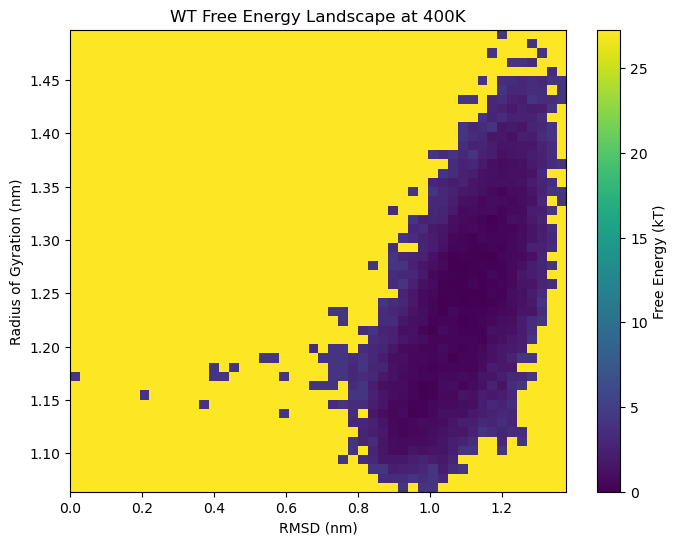

In [15]:
# FREE ENERGY LANDSCAPE for WT

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d

# =========================================================
# LOAD DATA
# =========================================================

# Replace with your arrays
# Example:
# rmsd_wt = ...
# rg_wt = ...

rmsd = rmsd_wt
rg = rg_wt

# =========================================================
# 2D HISTOGRAM
# =========================================================

H, xedges, yedges, binnumber = binned_statistic_2d(
    rmsd,
    rg,
    None,
    statistic='count',
    bins=50
)

# Avoid zeros
H = H + 1e-10

# =========================================================
# FREE ENERGY
# F = -ln(P)
# =========================================================

P = H / np.sum(H)

F = -np.log(P)

# Normalize
F = F - np.min(F)

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(8,6))

extent = [
    xedges[0],
    xedges[-1],
    yedges[0],
    yedges[-1]
]

plt.imshow(
    F.T,
    origin='lower',
    extent=extent,
    aspect='auto',
    cmap='viridis'
)

plt.colorbar(label='Free Energy (kT)')

plt.xlabel('RMSD (nm)')
plt.ylabel('Radius of Gyration (nm)')

plt.title('WT Free Energy Landscape at 400K')

plt.show()

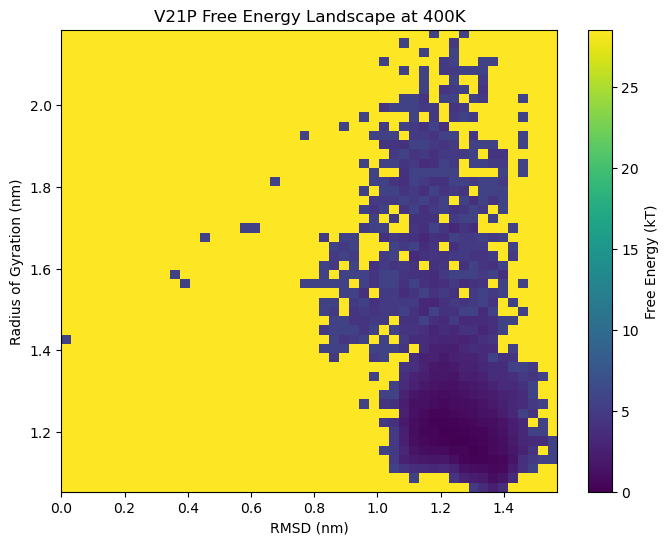

In [16]:
# FREE ENERGY LANDSCAPE for V21P

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d

# =========================================================
# LOAD DATA
# =========================================================

# Replace with your arrays
# Example:
# rmsd_wt = ...
# rg_wt = ...

rmsd = rmsd_v21p
rg = rg_v21p

# =========================================================
# 2D HISTOGRAM
# =========================================================

H, xedges, yedges, binnumber = binned_statistic_2d(
    rmsd,
    rg,
    None,
    statistic='count',
    bins=50
)

# Avoid zeros
H = H + 1e-10

# =========================================================
# FREE ENERGY
# F = -ln(P)
# =========================================================https://chemistry.du.ac.in/pvenkatesu/#

P = H / np.sum(H)

F = -np.log(P)

# Normalize
F = F - np.min(F)

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(8,6))

extent = [
    xedges[0],
    xedges[-1],
    yedges[0],
    yedges[-1]
]

plt.imshow(
    F.T,
    origin='lower',
    extent=extent,
    aspect='auto',
    cmap='viridis'
)

plt.colorbar(label='Free Energy (kT)')

plt.xlabel('RMSD (nm)')
plt.ylabel('Radius of Gyration (nm)')

plt.title('V21P Free Energy Landscape at 400K')

plt.show()

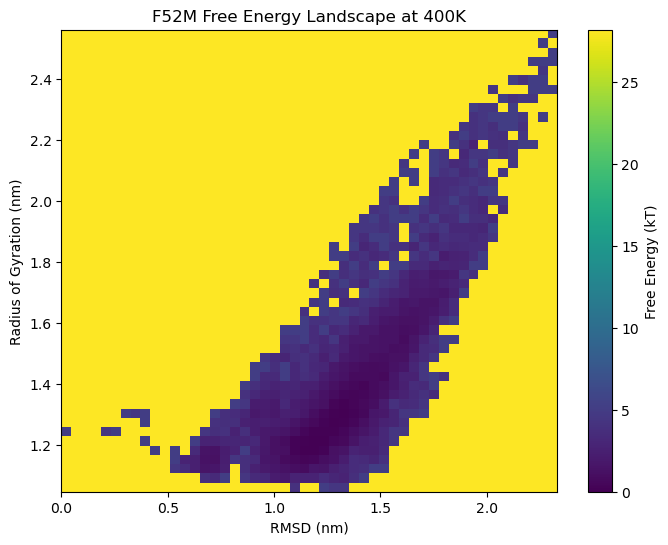

In [21]:
# FREE ENERGY LANDSCAPE for V21P

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d

# =========================================================
# LOAD DATA
# =========================================================

# Replace with your arrays
# Example:
# rmsd_wt = ...
# rg_wt = ...

rmsd = rmsd_f52m
rg = rg_f52m

# =========================================================
# 2D HISTOGRAM
# =========================================================

H, xedges, yedges, binnumber = binned_statistic_2d(
    rmsd,
    rg,
    None,
    statistic='count',
    bins=50
)

# Avoid zeros
H = H + 1e-10

# =========================================================
# FREE ENERGY
# F = -ln(P)
# =========================================================

P = H / np.sum(H)

F = -np.log(P)

# Normalize
F = F - np.min(F)

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(8,6))

extent = [
    xedges[0],
    xedges[-1],
    yedges[0],
    yedges[-1]
]

plt.imshow(
    F.T,
    origin='lower',
    extent=extent,
    aspect='auto',
    cmap='viridis'
)

plt.colorbar(label='Free Energy (kT)')

plt.xlabel('RMSD (nm)')
plt.ylabel('Radius of Gyration (nm)')

plt.title('F52M Free Energy Landscape at 400K')

plt.show()

In [1]:
import mdtraj as md
import numpy as np

def compute_mean_sasa(topology, trajectory):

    traj = md.load(trajectory, top=topology)

    # SASA per atom
    sasa = md.shrake_rupley(
        traj,
        probe_radius=0.14,   # 1.4 Å
        mode='atom'
    )

    total_sasa = sasa.sum(axis=1)

    return {
        "mean_sasa": np.mean(total_sasa),
        "std_sasa": np.std(total_sasa)
    }

In [4]:
result = compute_mean_sasa(
    "/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_solvated.pdb",
    "/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_trajectory.dcd"
)

print(result)

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
{'mean_sasa': np.float32(207.93544), 'std_sasa': np.float32(2.5462162)}


In [5]:
import mdtraj as md
import numpy as np

traj = md.load(
    "/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_trajectory.dcd",
    top="/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_solvated.pdb"
)

protein = traj.topology.select("protein")

sasa = md.shrake_rupley(
    traj,
    probe_radius=0.14,
    mode='atom'
)

protein_sasa = sasa[:, protein].sum(axis=1)

print(
    protein_sasa.mean(),
    protein_sasa.std()
)

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
0.10879958 0.071338125


In [6]:
print("Total atoms:", traj.n_atoms)
print("Protein atoms:", len(protein))

Total atoms: 11478
Protein atoms: 855


In [7]:
for chain in traj.topology.chains:
    print(chain)

for residue in list(traj.topology.residues)[:20]:
    print(residue)

MET1
THR2
TYR3
LYS4
LEU5
ILE6
LEU7
ASN8
GLY9
LYS10
THR11
LEU12
LYS13
GLY14
GLU15
THR16
THR17
THR18
GLU19
ALA20


In [8]:
print(sasa.shape)

(4970, 11478)


In [9]:
print("Total SASA:", sasa.sum(axis=1).mean())

print("Protein atoms selected:", len(protein))

print("Protein SASA:", sasa[:, protein].sum(axis=1).mean())

Total SASA: 207.93544
Protein atoms selected: 855
Protein SASA: 0.10879958


In [10]:
resnames = set(res.name for res in traj.topology.residues)
print(sorted(resnames))

['ALA', 'ASN', 'ASP', 'CL', 'GLN', 'GLU', 'GLY', 'HOH', 'ILE', 'LEU', 'LYS', 'MET', 'NA', 'PHE', 'THR', 'TRP', 'TYR', 'VAL']


In [11]:
sasa_res = md.shrake_rupley(
    traj,
    probe_radius=0.14,
    mode="residue"
)

print(sasa_res.shape)
print(sasa_res[0,:10])
print(sasa_res[0].sum())

(4970, 3613)
[0.         0.         0.         0.         0.         0.
 0.         0.00223221 0.         0.        ]
205.14694


In [12]:
import mdtraj as md
import numpy as np

traj = md.load(
    "/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_trajectory.dcd",
    top="/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_solvated.pdb"
)

protein = traj.topology.select("protein")

sasa = md.shrake_rupley(
    traj,
    probe_radius=0.14,
    mode='residue'
)

protein_sasa = sasa[:, protein].sum(axis=1)

print(
    "Mean SASA (nm²):",
    protein_sasa.mean()
)

print(
    "Mean SASA (Å²):",
    protein_sasa.mean()*100
)

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Mean SASA (nm²): 47.050835
Mean SASA (Å²): 4705.0835


In [13]:
import mdtraj as md
import numpy as np

traj = md.load(
    "/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_trajectory.dcd",
    top="/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_solvated.pdb"
)

protein = traj.topology.select("protein")

sasa = md.shrake_rupley(
    traj,
    probe_radius=0.14,
    mode="residue"
)

total_sasa = sasa.sum(axis=1)

print("Mean SASA (nm²):", total_sasa.mean())
print("Mean SASA (Å²):", total_sasa.mean()*100)

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Mean SASA (nm²): 207.93544
Mean SASA (Å²): 20793.545


In [14]:
protein_residues = [
    r.index
    for r in traj.topology.residues
    if r.is_protein
]

In [17]:
sasa = md.shrake_rupley(
    traj,
    probe_radius=0.14,
    mode="residue"
)

protein_sasa = sasa[:, protein_residues].sum(axis=1)

print("Mean SASA (nm²):", protein_sasa.mean())
print("Mean SASA (Å²):", protein_sasa.mean()*100)

Mean SASA (nm²): 0.108799584
Mean SASA (Å²): 10.879958


In [16]:
print("Number of residues:", traj.n_residues)

print(
    "Protein residues:",
    len([r for r in traj.topology.residues if r.is_protein])
)

Number of residues: 3613
Protein residues: 56


In [1]:
import pandas as pd

sel = pd.read_csv("selected_mutants.csv")

print(sel["y"].describe())
print(sel.sort_values("y").head())
print(sel.sort_values("y").tail())

count    50.000000
mean      0.264000
std       1.007135
min      -1.815000
25%      -0.430575
50%       0.154600
75%       0.776075
max       2.968000
Name: y, dtype: float64
                                                    x  name       y  pos
26  TYKLILNGKTLKGETTTEAVDAATALKVFKQYANDNGVDGEWTYDD...  E27L -1.8150   27
3   TYKLILNGKTLKLETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...  G14L -1.2500   14
6   TYKLILNGKTLKGETTTFAVDAATAEKVFKQYANDNGVDGEWTYDD...  E19F -0.8412   19
0   TYKLILNGKTLKGETTTEAPDAATAEKVFKQYANDNGVDGEWTYDD...  V21P -0.8258   21
44  TYKLILNGKTLKGETTTEAVDAKTAEKVFKQYANDNGVDGEWTYDD...  A24K -0.7753   24
                                                    x  name      y  pos
48  TYKLILNEKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...  G09E  1.997    9
8   TYKAILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...  L05A  2.013    5
17  TYKLILNGKTLKGETTTEAVDAATSEKVFKQYANDNGVDGEWTYDD...  A26S  2.330   26
1   TYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...  F52M  2.706   52
49  TYKLILNGKTLKGETTTEAVDA

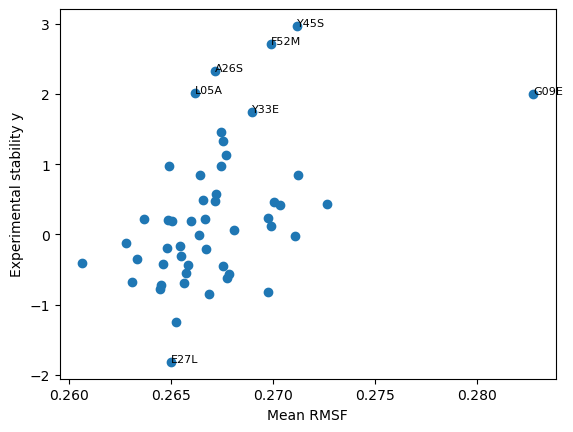

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

feat = pd.read_csv("explicit_features.csv")
sel = pd.read_csv("selected_mutants.csv")

merged = feat.merge(
    sel[["name","y"]],
    left_on="mutant",
    right_on="name"
)

plt.scatter(
    merged["mean_rmsf"],
    merged["y"]
)

for _,r in merged.iterrows():
    if abs(r["y"]) > 1.5:
        plt.text(
            r["mean_rmsf"],
            r["y"],
            r["mutant"],
            fontsize=8
        )

plt.xlabel("Mean RMSF")
plt.ylabel("Experimental stability y")
plt.show()

In [3]:
cols = [
    "mean_rmsf",
    "std_rg",
    "mean_rmsd",
    "prot_water_hbonds"
]

print(merged[cols].corr())

                   mean_rmsf    std_rg  mean_rmsd  prot_water_hbonds
mean_rmsf           1.000000  0.577918   0.509032           0.030559
std_rg              0.577918  1.000000   0.373066           0.060113
mean_rmsd           0.509032  0.373066   1.000000          -0.009156
prot_water_hbonds   0.030559  0.060113  -0.009156           1.000000


In [4]:
import pandas as pd

feat = pd.read_csv("explicit_features.csv")
sasa = pd.read_csv("sasa_features.csv")
sel  = pd.read_csv("selected_mutants.csv")

df = feat.merge(
    sasa[["mutant", "std_sasa"]],
    on="mutant",
    how="left"
)

df = df.merge(
    sel[["name", "y"]],
    left_on="mutant",
    right_on="name"
)

print(df.shape)
print(df.head())

(50, 30)
  mutant        mean_PE  mean_density  mean_rmsd  rmsd_plateau  mean_rmsf  \
0   V21P            NaN           NaN   0.381703      0.379106   0.269767   
1   F52M            NaN           NaN   0.411996      0.406639   0.269876   
2   T51M -118876.881681      1.007794   0.404918      0.405788   0.264909   
3   G14L            NaN           NaN   0.418026      0.418616   0.265253   
4   D47Y -130020.441470      1.003028   0.390133      0.391077   0.263348   

   max_rmsf    mean_Q         std_Q    mean_rg  ...  delta_mean_Q  \
0  0.374185  0.949091  4.801640e-09  10.558072  ...      0.000562   
1  0.356671  0.948339  4.061297e-09  10.602566  ...     -0.000190   
2  0.352328  0.947955  2.174938e-09  10.561134  ...     -0.000574   
3  0.365598  0.948148  3.168005e-09  10.587554  ...     -0.000381   
4  0.350008  0.948718  3.872901e-09  10.629268  ...      0.000189   

    delta_std_Q  delta_mean_rg  delta_std_rg  delta_sc_hbonds  \
0  1.113922e-09      -0.049700     -0.004923    

In [5]:
from scipy.stats import spearmanr

features = [
    "mean_rmsf",
    "std_rg",
    "mean_rmsd",
    "prot_water_hbonds",
    "std_sasa"
]

for f in features:
    rho, p = spearmanr(df[f], df["y"])
    print(f"{f:20s} rho={rho:+.3f} p={p:.4f}")

mean_rmsf            rho=+0.466 p=0.0007
std_rg               rho=+0.365 p=0.0092
mean_rmsd            rho=+0.308 p=0.0294
prot_water_hbonds    rho=+0.283 p=0.0465
std_sasa             rho=+0.279 p=0.0501


In [6]:
import numpy as np

from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

features = [
    "mean_rmsf",
    "std_rg",
    "mean_rmsd",
    "prot_water_hbonds",
    "std_sasa"
]

X = df[features].values
y = df["y"].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

loo = LeaveOneOut()

preds = np.zeros(len(y))

for train_idx, test_idx in loo.split(X):

    model = Ridge(alpha=1.0)

    model.fit(
        X[train_idx],
        y[train_idx]
    )

    preds[test_idx] = model.predict(
        X[test_idx]
    )

rho, p = spearmanr(preds, y)

print("\nLOOCV performance")
print(f"Spearman rho = {rho:.3f}")
print(f"p-value      = {p:.4g}")


LOOCV performance
Spearman rho = 0.436
p-value      = 0.001561


In [7]:
from scipy.stats import spearmanr

rho_single, _ = spearmanr(
    df["mean_rmsf"],
    df["y"]
)

rho_model, _ = spearmanr(
    preds,
    y
)

print("Best single feature:", rho_single)
print("Combined model:     ", rho_model)

Best single feature: 0.4656422569027611
Combined model:      0.43577430972388953


In [8]:
model = Ridge(alpha=1.0)

model.fit(X, y)

for feat, coef in zip(features, model.coef_):
    print(f"{feat:20s} {coef:+.4f}")

mean_rmsf            +0.2794
std_rg               +0.0497
mean_rmsd            +0.1724
prot_water_hbonds    +0.2640
std_sasa             +0.1542


### 17th June, 2026

In [1]:
import MDAnalysis as mda
from MDAnalysis.analysis import rms

u = mda.Universe(
    "/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_final.pdb",
    "/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_trajectory.dcd"
)

ca = u.select_atoms("protein and name CA")

r = rms.RMSF(ca).run()

print("Mean RMSF =", r.rmsf.mean())
print("Max RMSF  =", r.rmsf.max())

/home/feynman/miniconda3/envs/venv/lib/python3.13/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Mean RMSF = 0.2772410440264061
Max RMSF  = 0.5035592430290995


/home/feynman/miniconda3/envs/venv/lib/python3.13/site-packages/MDAnalysis/analysis/rms.py:1000: DeprecationWarning: The `rmsf` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


In [2]:
import MDAnalysis as mda
from MDAnalysis.analysis import align, rms
import tempfile

u = mda.Universe(
    "/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_final.pdb",
    "/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_trajectory.dcd"
)

ref = mda.Universe(
    "/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_final.pdb"
)

tmp = tempfile.NamedTemporaryFile(suffix=".dcd")

align.AlignTraj(
    u,
    ref,
    select="protein and backbone",
    filename=tmp.name
).run()

u_aligned = mda.Universe(
    "/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_final.pdb",
    tmp.name
)

ca = u_aligned.select_atoms("protein and name CA")

r = rms.RMSF(ca).run()

print("Aligned RMSF =", r.rmsf.mean())

Aligned RMSF = 0.2564790793172333


In [3]:
import MDAnalysis as mda
from MDAnalysis.analysis import contacts
import numpy as np

u = mda.Universe(
    "/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_final.pdb",
    "/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_trajectory.dcd"
)

ref = mda.Universe(
    "/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_final.pdb"
)

ca_u = u.select_atoms("protein and name CA")
ca_r = ref.select_atoms("protein and name CA")

Q_run = contacts.Contacts(
    u,
    select=(ca_u, ca_u),
    refgroup=(ca_r, ca_r),
    method="soft_cut",
    radius=8.0
).run()

Q = Q_run.timeseries[:,1]

print("Mean Q =", np.mean(Q))
print("Min Q  =", np.min(Q))
print("Max Q  =", np.max(Q))

Mean Q = 0.9485293442014717
Min Q  = 0.9485293043200089
Max Q  = 0.948529360824052


/home/feynman/miniconda3/envs/venv/lib/python3.13/site-packages/MDAnalysis/analysis/contacts.py:567: DeprecationWarning: The `timeseries` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.timeseries` instead
  warnings.warn(wmsg, DeprecationWarning)


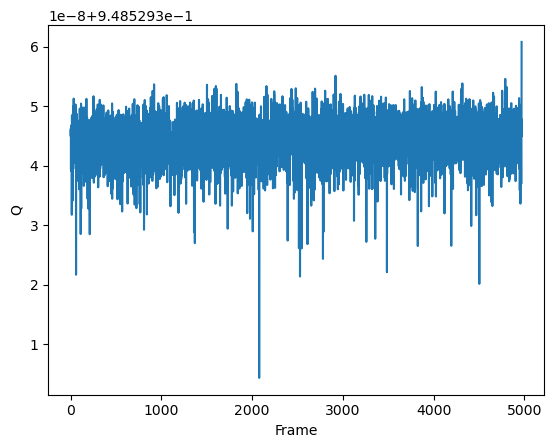

In [4]:
import matplotlib.pyplot as plt

plt.plot(Q)
plt.xlabel("Frame")
plt.ylabel("Q")
plt.show()

In [5]:
import pandas as pd

df = pd.read_csv("explicit_features.csv")
sel = pd.read_csv("selected_mutants.csv")

merged = df.merge(
    sel[["name","y"]],
    left_on="mutant",
    right_on="name"
)

print(
    merged.sort_values("y")
    [["mutant","y","mean_Q"]]
    .head(10)
)

print()

print(
    merged.sort_values("y")
    [["mutant","y","mean_Q"]]
    .tail(10)
)

   mutant       y    mean_Q
26   E27L -1.8150  0.947955
3    G14L -1.2500  0.948148
6    E19F -0.8412  0.948339
0    V21P -0.8258  0.949091
44   A24K -0.7753  0.948339
21   T17Y -0.7134  0.948718
40   N37H -0.6965  0.948529
41   T25H -0.6744  0.948529
47   D22S -0.6246  0.948718
23   T18F -0.5632  0.948529

   mutant       y    mean_Q
2    T51M  0.9797  0.947955
5    L07T  1.1350  0.948339
29   K50D  1.3290  0.947761
9    A34N  1.4610  0.948339
31   Y33E  1.7390  0.948148
48   G09E  1.9970  0.947955
8    L05A  2.0130  0.948339
17   A26S  2.3300  0.948529
1    F52M  2.7060  0.948339
49   Y45S  2.9680  0.948905


In [6]:
import pandas as pd

log = pd.read_csv(
    "/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_log.csv"
)

print(log.columns)

EmptyDataError: No columns to parse from file

In [7]:
import matplotlib.pyplot as plt
import MDAnalysis as mda
from MDAnalysis.analysis import align, rms
import tempfile

def get_rmsf(mut):

    u = mda.Universe(
        f"/data/openmm_out/1PGA_mutations/explicit_solvent/{mut}_rep1/{mut}_rep1_final.pdb",
        f"/data/openmm_out/1PGA_mutations/explicit_solvent/{mut}_rep1/{mut}_rep1_trajectory.dcd"
    )

    ref = mda.Universe(
        f"/data/openmm_out/1PGA_mutations/explicit_solvent/{mut}_rep1/{mut}_rep1_final.pdb"
    )

    tmp = tempfile.NamedTemporaryFile(suffix=".dcd")

    align.AlignTraj(
        u,
        ref,
        select="protein and backbone",
        filename=tmp.name
    ).run()

    ua = mda.Universe(
        f"/data/openmm_out/1PGA_mutations/explicit_solvent/{mut}_rep1/{mut}_rep1_final.pdb",
        tmp.name
    )

    ca = ua.select_atoms("protein and name CA")

    return rms.RMSF(ca).run().rmsf

/home/feynman/miniconda3/envs/venv/lib/python3.13/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"
/home/feynman/miniconda3/envs/venv/lib/python3.13/site-packages/MDAnalysis/analysis/rms.py:1000: DeprecationWarning: The `rmsf` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


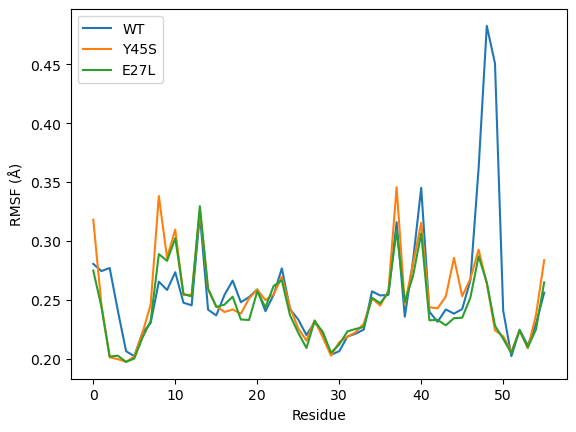

In [8]:
wt   = get_rmsf("1PGA")
good = get_rmsf("Y45S")   # highly stabilizing
bad  = get_rmsf("E27L")   # strongly destabilizing

plt.plot(wt,label="WT")
plt.plot(good,label="Y45S")
plt.plot(bad,label="E27L")

plt.legend()
plt.xlabel("Residue")
plt.ylabel("RMSF (Å)")
plt.show()

In [9]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

feat = pd.read_csv("explicit_features.csv")
sel  = pd.read_csv("selected_mutants.csv")

merged = feat.merge(
    sel[["name","y"]],
    left_on="mutant",
    right_on="name"
)

rho,p = spearmanr(
    merged["mean_rmsf"],
    merged["y"]
)

print("Original:")
print(rho,p)

Original:
0.4656422569027611 0.000655294776937041


/home/feynman/miniconda3/envs/venv/lib/python3.13/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


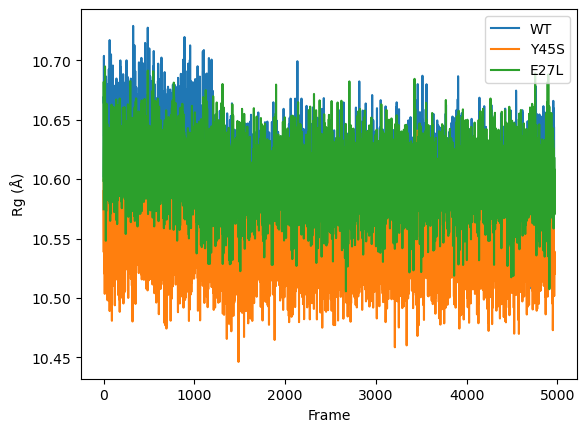

In [10]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

def rg_trace(mut):

    u = mda.Universe(
        f"/data/openmm_out/1PGA_mutations/explicit_solvent/{mut}_rep1/{mut}_rep1_final.pdb",
        f"/data/openmm_out/1PGA_mutations/explicit_solvent/{mut}_rep1/{mut}_rep1_trajectory.dcd"
    )

    prot = u.select_atoms("protein")

    rg = []

    for ts in u.trajectory:
        rg.append(prot.radius_of_gyration())

    return np.array(rg)

wt  = rg_trace("1PGA")
good = rg_trace("Y45S")
bad  = rg_trace("E27L")

plt.plot(wt,label="WT")
plt.plot(good,label="Y45S")
plt.plot(bad,label="E27L")

plt.legend()
plt.ylabel("Rg (Å)")
plt.xlabel("Frame")
plt.show()

In [11]:
print("WT ",wt.mean(),wt.std())
print("Y45S",good.mean(),good.std())
print("E27L",bad.mean(),bad.std())

WT  10.607772549630583 0.03210255361290751
Y45S 10.545474628117187 0.026877588346202973
E27L 10.60126904819096 0.026393993946694515


In [12]:
import pandas as pd

feat = pd.read_csv("explicit_features.csv")
sel  = pd.read_csv("selected_mutants.csv")

merged = feat.merge(
    sel[["name","y"]],
    left_on="mutant",
    right_on="name"
)

print(
    merged.sort_values("y")
    [["mutant","y","mean_rmsf","std_rg","mean_rg"]]
)

print()

print(
    merged.sort_values("y",ascending=False)
    [["mutant","y","mean_rmsf","std_rg","mean_rg"]]
)

   mutant         y  mean_rmsf    std_rg    mean_rg
26   E27L -1.815000   0.264985  0.026394  10.601269
3    G14L -1.250000   0.265253  0.026919  10.587554
6    E19F -0.841200   0.266878  0.025697  10.585175
0    V21P -0.825800   0.269767  0.027179  10.558072
44   A24K -0.775300   0.264441  0.025726  10.606599
21   T17Y -0.713400   0.264505  0.026507  10.564261
40   N37H -0.696500   0.265655  0.025999  10.566752
41   T25H -0.674400   0.263068  0.026252  10.624842
47   D22S -0.624600   0.267732  0.026377  10.542130
23   T18F -0.563200   0.267854  0.026917  10.603085
35   Y03F -0.549900   0.265720  0.026511  10.558556
12   K28N -0.442800   0.267555  0.026503  10.549543
39   G41R -0.433700   0.265852  0.025954  10.690761
22   T11H -0.421200   0.264614  0.026338  10.613425
14   D36Q -0.408900   0.260651  0.025631  10.571849
4    D47Y -0.354600   0.263348  0.025702  10.629268
38   T44H -0.306500   0.265496  0.026562  10.563656
24   Q32S -0.202700   0.266703  0.025612  10.571634
25   G38Q -0

In [13]:
from scipy.stats import spearmanr

rho,p = spearmanr(
    merged["delta_mean_rg"],
    merged["y"]
)

print(rho,p)

-0.027322929171668665 0.8506017192354086


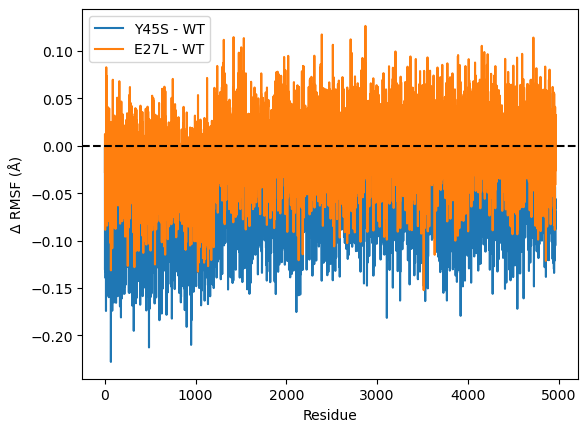

In [14]:
delta_good = good - wt
delta_bad  = bad - wt

plt.plot(delta_good,label="Y45S - WT")
plt.plot(delta_bad,label="E27L - WT")

plt.axhline(0,color="k",ls="--")

plt.xlabel("Residue")
plt.ylabel("Δ RMSF (Å)")
plt.legend()
plt.show()

In [15]:
print(wt.shape)
print(good.shape)
print(bad.shape)

(4970,)
(4970,)
(4970,)


In [16]:
from MDAnalysis.analysis import align, rms
import MDAnalysis as mda
import tempfile

def residue_rmsf(mut):

    u = mda.Universe(
        f"/data/openmm_out/1PGA_mutations/explicit_solvent/{mut}_rep1/{mut}_rep1_final.pdb",
        f"/data/openmm_out/1PGA_mutations/explicit_solvent/{mut}_rep1/{mut}_rep1_trajectory.dcd"
    )

    ref = mda.Universe(
        f"/data/openmm_out/1PGA_mutations/explicit_solvent/{mut}_rep1/{mut}_rep1_final.pdb"
    )

    tmp = tempfile.NamedTemporaryFile(suffix=".dcd")

    align.AlignTraj(
        u,
        ref,
        select="protein and backbone",
        filename=tmp.name
    ).run()

    ua = mda.Universe(
        f"/data/openmm_out/1PGA_mutations/explicit_solvent/{mut}_rep1/{mut}_rep1_final.pdb",
        tmp.name
    )

    ca = ua.select_atoms("protein and name CA")

    r = rms.RMSF(ca).run()

    return r.rmsf

/home/feynman/miniconda3/envs/venv/lib/python3.13/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"
/home/feynman/miniconda3/envs/venv/lib/python3.13/site-packages/MDAnalysis/analysis/rms.py:1000: DeprecationWarning: The `rmsf` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


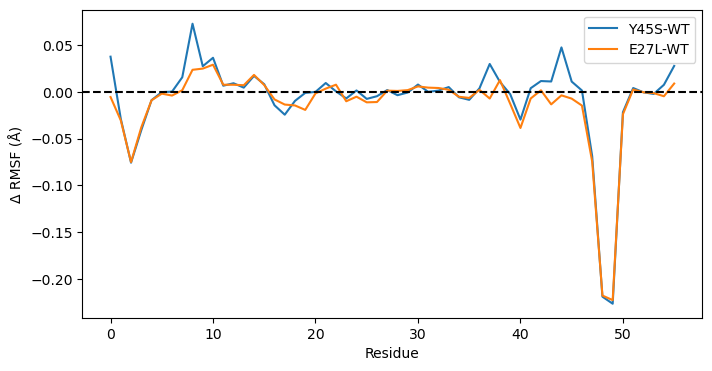

In [17]:
wt   = residue_rmsf("1PGA")
good = residue_rmsf("Y45S")
bad  = residue_rmsf("E27L")

plt.figure(figsize=(8,4))

plt.plot(good-wt,label="Y45S-WT")
plt.plot(bad-wt,label="E27L-WT")

plt.axhline(0,color='k',ls='--')

plt.xlabel("Residue")
plt.ylabel("Δ RMSF (Å)")
plt.legend()

plt.show()

### 18th June, 2026

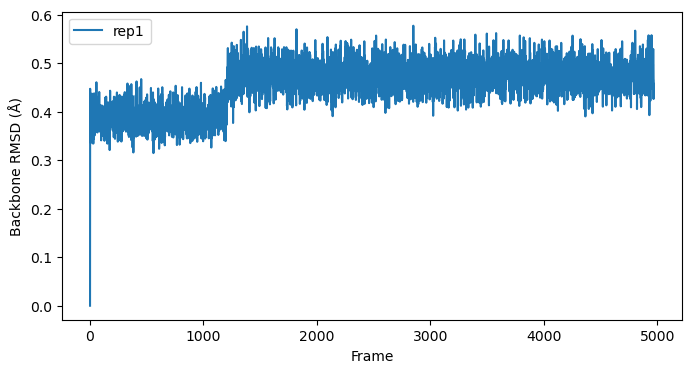

In [18]:
import MDAnalysis as mda
from MDAnalysis.analysis import rms
import matplotlib.pyplot as plt
import numpy as np

def rmsd_trace(rep):

    u = mda.Universe(
        f"/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_final.pdb",
        f"/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_trajectory.dcd"
    )

    R = rms.RMSD(
        u,
        u,
        select="protein and backbone"
    ).run()

    return R.results.rmsd[:,2]

plt.figure(figsize=(8,4))

# for rep in [1,2,3]:
plt.plot(rmsd_trace(1),label=f"rep1")
# plt.plot(rmsd_trace(2),label=f"rep2")
# plt.plot(rmsd_trace(3),label=f"rep3")

plt.xlabel("Frame")
plt.ylabel("Backbone RMSD (Å)")
plt.legend()
plt.show()

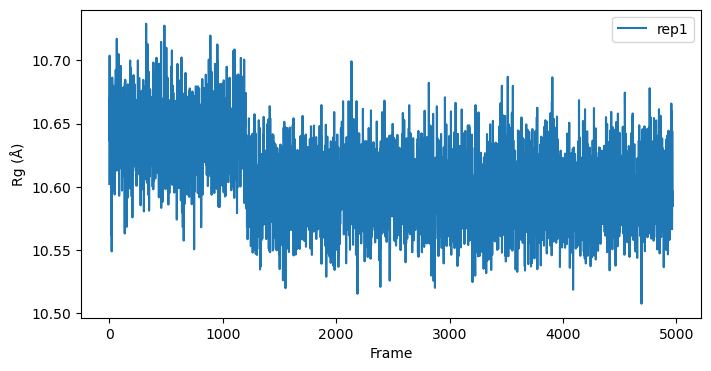

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def rg_trace(rep):

    u = mda.Universe(
        f"/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_final.pdb",
        f"/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_trajectory.dcd"
    )

    prot = u.select_atoms("protein")

    rg=[]

    for ts in u.trajectory:
        rg.append(prot.radius_of_gyration())

    return np.array(rg)

plt.figure(figsize=(8,4))

# for rep in [1,2,3]:
plt.plot(rg_trace(1),label=f"rep1")

plt.xlabel("Frame")
plt.ylabel("Rg (Å)")
plt.legend()
plt.show()

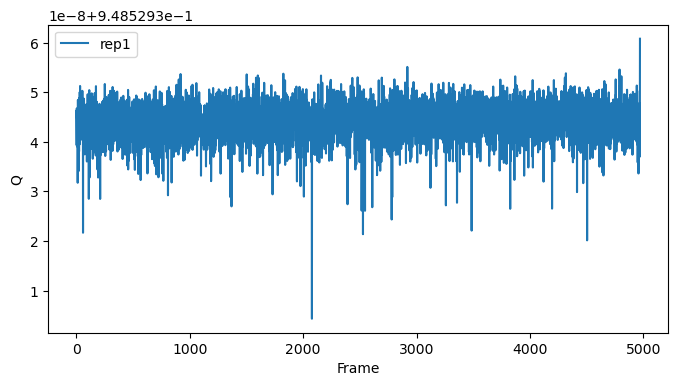

In [20]:
from MDAnalysis.analysis import contacts
import numpy as np
import matplotlib.pyplot as plt

def Q_trace(rep):

    pdb = f"/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_final.pdb"
    dcd = f"/data/openmm_out/1PGA_mutations/explicit_solvent/1PGA_rep1/1PGA_rep1_trajectory.dcd"

    u = mda.Universe(pdb,dcd)
    ref = mda.Universe(pdb)

    ca_u = u.select_atoms("protein and name CA")
    ca_r = ref.select_atoms("protein and name CA")

    q = contacts.Contacts(
        u,
        select=(ca_u,ca_u),
        refgroup=(ca_r,ca_r),
        method="soft_cut",
        radius=8.0
    ).run()

    return q.results.timeseries[:,1]

plt.figure(figsize=(8,4))

#for rep in [1,2,3]:
plt.plot(Q_trace(1),label=f"rep1")

plt.xlabel("Frame")
plt.ylabel("Q")
plt.legend()
plt.show()

In [21]:
import MDAnalysis as mda
from MDAnalysis.analysis import rms
import numpy as np

def rmsd_trace(mut):

    u = mda.Universe(
        f"/data/openmm_out/1PGA_mutations/explicit_solvent/{mut}_rep1/{mut}_rep1_final.pdb",
        f"/data/openmm_out/1PGA_mutations/explicit_solvent/{mut}_rep1/{mut}_rep1_trajectory.dcd"
    )

    R = rms.RMSD(
        u,
        u,
        select="protein and backbone"
    ).run()

    return R.results.rmsd[:,2]

In [22]:
def rg_trace(mut):

    u = mda.Universe(
        f"/data/openmm_out/1PGA_mutations/explicit_solvent/{mut}_rep1/{mut}_rep1_final.pdb",
        f"/data/openmm_out/1PGA_mutations/explicit_solvent/{mut}_rep1/{mut}_rep1_trajectory.dcd"
    )

    prot = u.select_atoms("protein")

    rg = []

    for ts in u.trajectory:
        rg.append(prot.radius_of_gyration())

    return np.array(rg)

In [23]:
from MDAnalysis.analysis import contacts

def q_trace(mut):

    pdb = (
        f"/data/openmm_out/1PGA_mutations/explicit_solvent/"
        f"{mut}_rep1/{mut}_rep1_final.pdb"
    )

    dcd = (
        f"/data/openmm_out/1PGA_mutations/explicit_solvent/"
        f"{mut}_rep1/{mut}_rep1_trajectory.dcd"
    )

    u = mda.Universe(pdb,dcd)
    ref = mda.Universe(pdb)

    q = contacts.Contacts(
        u,
        select=("protein and name CA",
                "protein and name CA"),
        refgroup=(
            ref.select_atoms("protein and name CA"),
            ref.select_atoms("protein and name CA")
        ),
        method="soft_cut",
        radius=8.0
    ).run()

    return q.results.timeseries[:,1]

In [24]:
wt_rmsd = rmsd_trace("1PGA")
good_rmsd = rmsd_trace("Y45S")
bad_rmsd = rmsd_trace("E27L")

wt_rg = rg_trace("1PGA")
good_rg = rg_trace("Y45S")
bad_rg = rg_trace("E27L")

wt_q = q_trace("1PGA")
good_q = q_trace("Y45S")
bad_q = q_trace("E27L")

In [25]:
import pandas as pd

summary = pd.DataFrame({

    "mutant": ["WT","Y45S","E27L"],

    "mean_rmsd": [
        wt_rmsd.mean(),
        good_rmsd.mean(),
        bad_rmsd.mean()
    ],

    "std_rmsd": [
        wt_rmsd.std(),
        good_rmsd.std(),
        bad_rmsd.std()
    ],

    "mean_rg": [
        wt_rg.mean(),
        good_rg.mean(),
        bad_rg.mean()
    ],

    "std_rg": [
        wt_rg.std(),
        good_rg.std(),
        bad_rg.std()
    ],

    "mean_q": [
        wt_q.mean(),
        good_q.mean(),
        bad_q.mean()
    ],

    "std_q": [
        wt_q.std(),
        good_q.std(),
        bad_q.std()
    ]

})

summary

,mutant,mean_rmsd,std_rmsd,mean_rg,std_rg,mean_q,std_q
0,WT,0.454623,0.047141,10.607773,0.032103,0.948529,3.687718e-09
1,Y45S,0.439675,0.029154,10.545475,0.026878,0.948905,3.264493e-09
2,E27L,0.408043,0.026701,10.601269,0.026394,0.947955,3.741927e-09


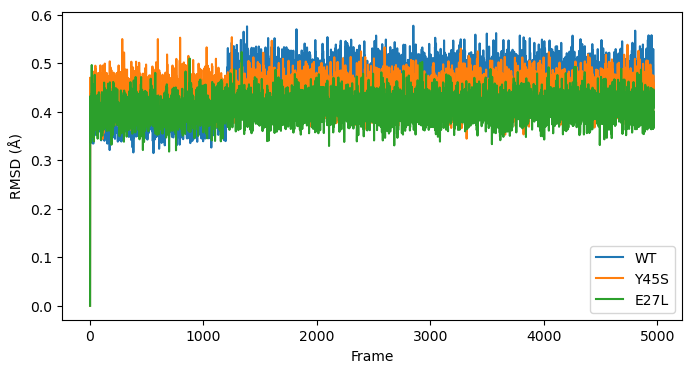

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(wt_rmsd,label="WT")
plt.plot(good_rmsd,label="Y45S")
plt.plot(bad_rmsd,label="E27L")

plt.ylabel("RMSD (Å)")
plt.xlabel("Frame")

plt.legend()
plt.show()

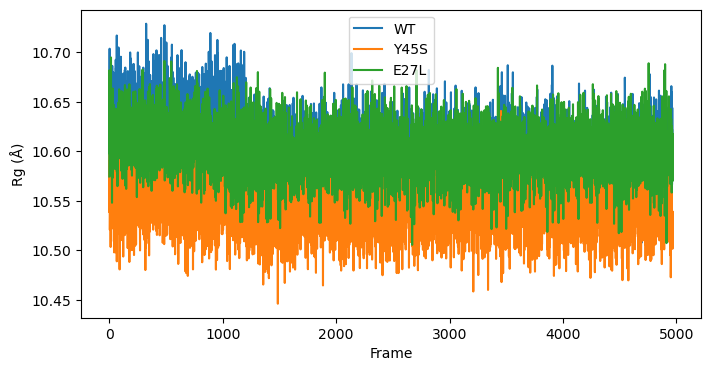

In [27]:
plt.figure(figsize=(8,4))

plt.plot(wt_rg,label="WT")
plt.plot(good_rg,label="Y45S")
plt.plot(bad_rg,label="E27L")

plt.ylabel("Rg (Å)")
plt.xlabel("Frame")

plt.legend()
plt.show()

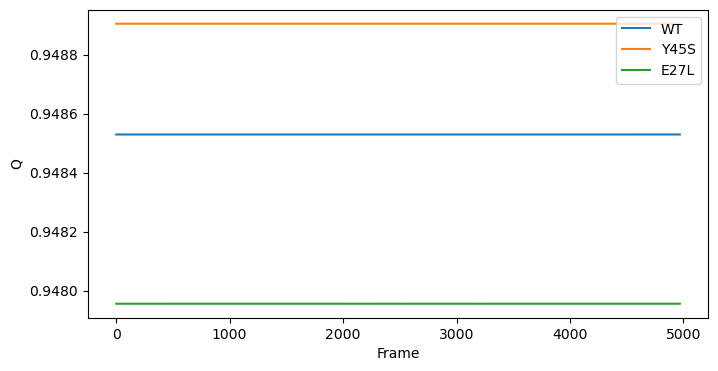

In [28]:
plt.figure(figsize=(8,4))

plt.plot(wt_q,label="WT")
plt.plot(good_q,label="Y45S")
plt.plot(bad_q,label="E27L")

plt.ylabel("Q")
plt.xlabel("Frame")

plt.legend()
plt.show()

In [30]:
from MDAnalysis.analysis import dssp

print("DSSP imported successfully")

DSSP imported successfully


In [31]:
import MDAnalysis as mda
from MDAnalysis.analysis import dssp
import numpy as np

def dssp_trace(mut):

    u = mda.Universe(
        f"/data/openmm_out/1PGA_mutations/explicit_solvent/{mut}_rep1/{mut}_rep1_final.pdb",
        f"/data/openmm_out/1PGA_mutations/explicit_solvent/{mut}_rep1/{mut}_rep1_trajectory.dcd"
    )

    D = dssp.DSSP(u).run()

    return D

In [32]:
wt_dssp   = dssp_trace("1PGA")
y45s_dssp = dssp_trace("Y45S")
e27l_dssp = dssp_trace("E27L")

/home/feynman/miniconda3/envs/venv/lib/python3.13/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


In [33]:
print(type(wt_dssp))

print(dir(wt_dssp))

<class 'MDAnalysis.analysis.dssp.dssp.DSSP'>
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_analysis_algorithm_is_parallelizable', '_compute', '_conclude', '_configure_backend', '_define_run_frames', '_frame_index', '_get_aggregator', '_get_coords', '_guess_hydrogens', '_heavy_atoms', '_hydrogens', '_prepare', '_prepare_sliced_trajectory', '_setup_computation_groups', '_setup_frames', '_single_frame', '_sliced_trajectory', '_trajectory', '_ts', '_verbose', 'frames', 'get_supported_backends', 'n_frames', 'parallelizable', 'results', 'run', 'start', 'step', 'stop', 'times']


In [34]:
wt_dssp.results.dssp

array([['-', 'E', 'E', ..., 'E', 'E', '-'],
       ['-', 'E', 'E', ..., 'E', 'E', '-'],
       ['-', 'E', 'E', ..., 'E', 'E', '-'],
       ...,
       ['-', 'E', 'E', ..., 'E', 'E', '-'],
       ['-', 'E', 'E', ..., 'E', 'E', '-'],
       ['-', 'E', 'E', ..., 'E', 'E', '-']], shape=(4970, 56), dtype='<U1')

In [35]:
print(wt_dssp.results.dssp.shape)

(4970, 56)


In [36]:
import numpy as np

def structured_fraction(D):

    ss = D.results.dssp

    structured = np.isin(
        ss,
        ["H","G","I","E","B"]
    )

    return structured.mean(axis=1)

wt_fold   = structured_fraction(wt_dssp)
y45s_fold = structured_fraction(y45s_dssp)
e27l_fold = structured_fraction(e27l_dssp)

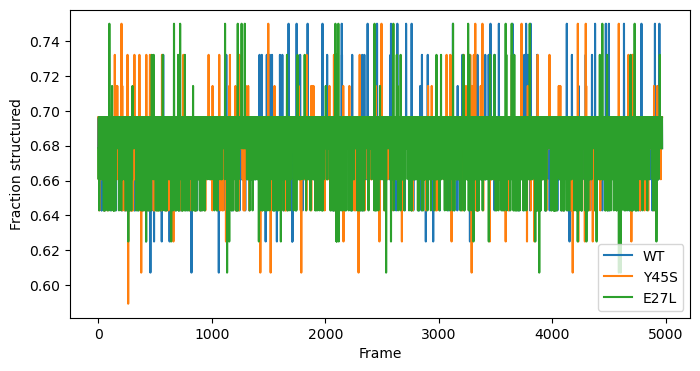

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(wt_fold,label="WT")
plt.plot(y45s_fold,label="Y45S")
plt.plot(e27l_fold,label="E27L")

plt.xlabel("Frame")
plt.ylabel("Fraction structured")

plt.legend()
plt.show()

In [38]:
print("WT   ", wt_fold.mean(), wt_fold.std())
print("Y45S ", y45s_fold.mean(), y45s_fold.std())
print("E27L ", e27l_fold.mean(), e27l_fold.std())

WT    0.6833105777522277 0.013400813208624537
Y45S  0.6866736131072146 0.013161460666836445
E27L  0.6829692440356425 0.01587633522296001


In [39]:
import numpy as np

def structured_fraction(D):

    ss = D.results.dssp

    structured = np.isin(
        ss,
        ["H", "E"]
    )

    return structured.mean(axis=1)

In [40]:
wt_fold   = structured_fraction(wt_dssp)
y45s_fold = structured_fraction(y45s_dssp)
e27l_fold = structured_fraction(e27l_dssp)

In [41]:
print("WT  :", wt_fold.mean(), wt_fold.std())
print("Y45S:", y45s_fold.mean(), y45s_fold.std())
print("E27L:", e27l_fold.mean(), e27l_fold.std())

WT  : 0.6833105777522277 0.013400813208624537
Y45S: 0.6866736131072146 0.013161460666836445
E27L: 0.6829692440356425 0.01587633522296001


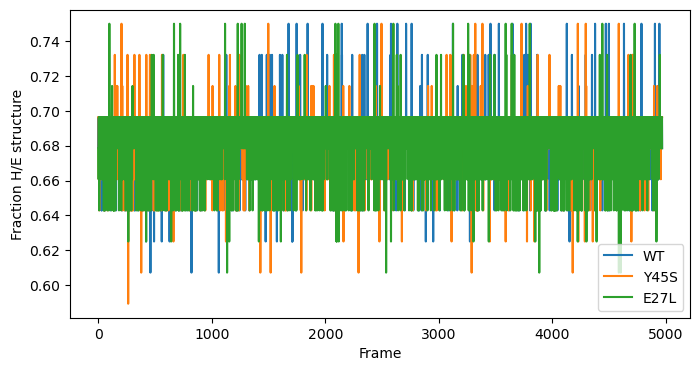

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(wt_fold, label="WT")
plt.plot(y45s_fold, label="Y45S")
plt.plot(e27l_fold, label="E27L")

plt.xlabel("Frame")
plt.ylabel("Fraction H/E structure")

plt.legend()

plt.show()

In [43]:
def beta_occupancy(D):

    ss = D.results.dssp

    beta = (ss == "E")

    return beta.mean(axis=0)

wt_beta   = beta_occupancy(wt_dssp)
y45s_beta = beta_occupancy(y45s_dssp)
e27l_beta = beta_occupancy(e27l_dssp)

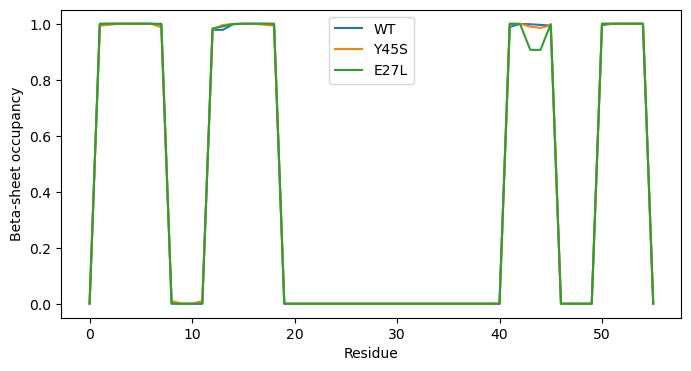

In [44]:
plt.figure(figsize=(8,4))

plt.plot(wt_beta,label="WT")
plt.plot(y45s_beta,label="Y45S")
plt.plot(e27l_beta,label="E27L")

plt.xlabel("Residue")
plt.ylabel("Beta-sheet occupancy")

plt.legend()
plt.show()

In [45]:
import openmm.app as app
print(app.forcefield._defaultDataDir)

AttributeError: module 'openmm.app.forcefield' has no attribute '_defaultDataDir'

In [46]:
import openmm.app as app
import os

# Get the directory where the forcefield module is located
module_dir = os.path.dirname(app.forcefield.__file__)

# The default built-in force fields are stored in the 'data' subdirectory
default_data_dir = os.path.join(module_dir, 'data')

print(default_data_dir)


/home/feynman/miniconda3/envs/venv/lib/python3.13/site-packages/openmm/app/data


In [47]:
import openmm.app as app
import os

# Find the built-in data directory
module_dir = os.path.dirname(app.forcefield.__file__)
data_dir = os.path.join(module_dir, 'data')

# Recursively scan and list all forcefield XML files
print("--- Available Built-in OpenMM Force Fields ---\n")
for root, dirs, files in os.walk(data_dir):
    # Filter for only .xml files
    xml_files = [f for f in files if f.endswith('.xml')]
    
    if xml_files:
        # Get relative path from the data directory to match usage syntax
        rel_path = os.path.relpath(root, data_dir)
        folder_prefix = "" if rel_path == "." else f"{rel_path}/"
        
        print(f"📁 Folder: {rel_path if rel_path != '.' else 'Root (data/)'}")
        for xml in sorted(xml_files):
            print(f"  └── {folder_prefix}{xml}")
        print()


--- Available Built-in OpenMM Force Fields ---

📁 Folder: Root (data/)
  └── amber03.xml
  └── amber03_obc.xml
  └── amber10.xml
  └── amber10_obc.xml
  └── amber14-all.xml
  └── amber19-all.xml
  └── amber96.xml
  └── amber96_obc.xml
  └── amber99Test.xml
  └── amber99_obc.xml
  └── amber99sb.xml
  └── amber99sbildn.xml
  └── amber99sbnmr.xml
  └── amberfb15.xml
  └── amoeba2009.xml
  └── amoeba2009_gk.xml
  └── amoeba2013.xml
  └── amoeba2013_gk.xml
  └── amoeba2018.xml
  └── amoeba2018_gk.xml
  └── charmm36.xml
  └── charmm36_2024.xml
  └── charmm_polar_2013.xml
  └── charmm_polar_2019.xml
  └── charmm_polar_2023.xml
  └── glycam-hydrogens.xml
  └── hydrogens.xml
  └── iamoeba.xml
  └── opc.xml
  └── opc3.xml
  └── pdbNames.xml
  └── residues.xml
  └── spce.xml
  └── swm4ndp.xml
  └── tip3p.xml
  └── tip3pfb.xml
  └── tip4pew.xml
  └── tip4pfb.xml
  └── tip5p.xml

📁 Folder: amber14
  └── amber14/DNA.OL15.xml
  └── amber14/DNA.bsc1.xml
  └── amber14/GLYCAM_06j-1.xml
  └── amber14/RNA